## Importação das bibliotecas e da base

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("MetaPosts.csv")



-----------------------

## Validação da base

Análise das colunas

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   rede_social           583 non-null    object 
 1   marca                 583 non-null    object 
 2   ano                   583 non-null    int64  
 3   mes                   583 non-null    int64  
 4   data_hora_criacao     583 non-null    object 
 5   dia_da_semana         583 non-null    object 
 6   link                  583 non-null    object 
 7   url_imagem            583 non-null    object 
 8   legenda               583 non-null    object 
 9   tipo                  583 non-null    object 
 10  alcance_organico      292 non-null    float64
 11  alcance_pago          292 non-null    float64
 12  alcance_total         583 non-null    int64  
 13  curtidas_e_reacoes    583 non-null    int64  
 14  comentarios           583 non-null    int64  
 15  compartilhamentos     5

Quantidade dos valores nulo de cada variável

In [4]:
df.isnull().sum()

rede_social               0
marca                     0
ano                       0
mes                       0
data_hora_criacao         0
dia_da_semana             0
link                      0
url_imagem                0
legenda                   0
tipo                      0
alcance_organico        291
alcance_pago            291
alcance_total             0
curtidas_e_reacoes        0
comentarios               0
compartilhamentos         0
cliques                   0
salvos                    0
views                   290
impressoes_organicas      0
impressoes_pagas          0
impressoes_totais         0
envolvimento              0
taxa_de_engajamento       0
dtype: int64

Quase metade dos dados de views, alcance orgânico e pago são nulos

In [5]:
df.duplicated().sum()

np.int64(0)

Não tem nenhuma linha duplicada

In [6]:
df["salvos"].value_counts()

salvos
0      369
1       70
2       40
3       34
5       18
4       14
6        8
7        6
8        5
14       2
9        2
16       2
29       1
174      1
40       1
17       1
109      1
25       1
28       1
23       1
19       1
114      1
56       1
13       1
18       1
Name: count, dtype: int64

Grande número de 0

In [7]:
df["alcance_organico"].value_counts()

alcance_organico
1777.0    3
2648.0    3
1034.0    2
1961.0    2
849.0     2
         ..
1770.0    1
1657.0    1
1756.0    1
1872.0    1
3329.0    1
Name: count, Length: 266, dtype: int64

Números normais porém com metade dos dados sendo nulos

In [8]:
df["alcance_pago"].value_counts()

alcance_pago
0.0    292
Name: count, dtype: int64

Metade dos dados de alcance pago são nulos e a outra apenas 0.0

In [9]:
df["views"].value_counts()

views
0.0        292
22614.0      1
Name: count, dtype: int64

Apenas uma linha das views é diferente de 0

In [10]:
df["impressoes_pagas"].value_counts()

impressoes_pagas
0         582
144817      1
Name: count, dtype: int64

In [11]:
df['salvos'].unique()

array([  1,   0,   4,  29,   2,   5,   3,  14,   9, 109,  40, 174,   7,
        16,   6,  17,  25,  28,  19,  23, 114,  56,   8,  13,  18])

Apenas uma linha das impressões pagas é diferente de 0

In [12]:
df.head()

,rede_social,marca,ano,mes,data_hora_criacao,dia_da_semana,link,url_imagem,legenda,tipo,...,comentarios,compartilhamentos,cliques,salvos,views,impressoes_organicas,impressoes_pagas,impressoes_totais,envolvimento,taxa_de_engajamento
0,Instagram,B Braun,2026,7,03/07/2026 12:01:47,Sexta-Feira,https://www.instagram.com/p/DaVHjZqjF3u,https://storage.googleapis.com/brv-valhalla-da...,E se você pudesse conhecer a tecnologia OMNI a...,reels,...,5,27,0,1,0.0,2571,0,2571,89,"0,0520163647"
1,Facebook,B Braun,2026,7,03/07/2026 12:01:06,Sexta-Feira,https://www.facebook.com/reel/2536486383534747/,https://storage.googleapis.com/brv-valhalla-da...,E se você pudesse conhecer a tecnologia OMNI a...,reels,...,0,0,0,0,NaN,74,0,75,4,"0,05797101449"
2,Facebook,B Braun,2026,7,02/07/2026 13:28:01,Quinta-Feira,https://www.facebook.com/reel/1610329023941411/,https://storage.googleapis.com/brv-valhalla-da...,Um hospital é movido por pessoas. Pessoas que ...,reels,...,0,0,1,0,NaN,219,0,219,5,"0,02380952381"
3,Instagram,B Braun,2026,7,02/07/2026 13:26:15,Quinta-Feira,https://www.instagram.com/p/DaSsbGZj7Oc,https://storage.googleapis.com/brv-valhalla-da...,Um hospital é movido por pessoas. Pessoas que ...,reels,...,0,6,0,0,0.0,1449,0,1449,64,"0,06189555126"
4,Instagram,B Braun,2026,6,29/06/2026 12:00:16,Segunda-Feira,https://www.instagram.com/p/DaK0SiaiMVL,https://storage.googleapis.com/brv-valhalla-da...,Higienizar as mãos é um protocolo de segurança...,carrossel,...,0,6,0,1,0.0,1536,0,1536,43,"0,05826558266"


-----------------------

## Tratamanto de variáveis 

Tranformar a taxa de engajamento para float para conseguir fazer os cálculos com ela

In [13]:

def obj_to_float(x):
    tranforma = float(x.replace(' ','')
                .replace(',', '.'))
    return tranforma

df['taxa_de_engajamento'] = df['taxa_de_engajamento'].apply(obj_to_float)


Transformar a data de object para datetime

In [14]:
df["data_hora_criacao"] = pd.to_datetime(
    df["data_hora_criacao"],
    format="%d/%m/%Y %H:%M:%S"
)

Excluir colunas que não tem dados suficientes

In [15]:
df = df.drop(columns=['views', 'impressoes_pagas', 'alcance_pago', 'alcance_organico'])

-----------------------

## Validação pós tratamento da base

In [16]:
df.isnull().sum()

rede_social             0
marca                   0
ano                     0
mes                     0
data_hora_criacao       0
dia_da_semana           0
link                    0
url_imagem              0
legenda                 0
tipo                    0
alcance_total           0
curtidas_e_reacoes      0
comentarios             0
compartilhamentos       0
cliques                 0
salvos                  0
impressoes_organicas    0
impressoes_totais       0
envolvimento            0
taxa_de_engajamento     0
dtype: int64

Nenhum valor nulo

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   rede_social           583 non-null    object        
 1   marca                 583 non-null    object        
 2   ano                   583 non-null    int64         
 3   mes                   583 non-null    int64         
 4   data_hora_criacao     583 non-null    datetime64[ns]
 5   dia_da_semana         583 non-null    object        
 6   link                  583 non-null    object        
 7   url_imagem            583 non-null    object        
 8   legenda               583 non-null    object        
 9   tipo                  583 non-null    object        
 10  alcance_total         583 non-null    int64         
 11  curtidas_e_reacoes    583 non-null    int64         
 12  comentarios           583 non-null    int64         
 13  compartilhamentos   

-Data foi para datetime

-Colunas com muitos valores nulo excluídas

-Taxa de engajamento tipo float64 agora


-----------------------

## Análise

**Análise dos números das métricas utilizadas**

In [18]:
df.describe()

,ano,mes,data_hora_criacao,alcance_total,curtidas_e_reacoes,comentarios,compartilhamentos,cliques,salvos,impressoes_organicas,impressoes_totais,envolvimento,taxa_de_engajamento
count,583.000000,583.000000,583,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000
mean,2025.161235,6.708405,2025-09-04 16:05:37.658662144,1600.878216,65.962264,3.471698,12.149228,9.881647,2.180103,3053.476844,3303.778731,93.644940,0.291930
min,2024.000000,1.000000,2024-10-01 19:44:48,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000
25%,2025.000000,4.000000,2025-04-08 21:38:17,167.500000,8.000000,0.000000,0.000000,0.000000,0.000000,308.500000,310.000000,12.000000,0.038462
50%,2025.000000,6.000000,2025-09-11 20:04:55,841.000000,30.000000,1.000000,2.000000,0.000000,0.000000,1367.000000,1369.000000,41.000000,0.057971
75%,2026.000000,10.000000,2026-02-24 18:29:07.500000,2068.000000,72.500000,3.000000,10.000000,3.000000,1.000000,3708.000000,3732.000000,97.500000,0.086552
max,2026.000000,12.000000,2026-07-03 12:01:47,91421.000000,1020.000000,71.000000,587.000000,1004.000000,174.000000,54751.000000,145970.000000,1826.000000,23.500000
std,0.640613,3.405178,NaN,4410.060534,104.281218,7.318160,40.969606,52.619245,10.504302,5173.343744,7860.052074,160.391175,1.302824


**Impressões Totais**

Desvio padrão é alto, indicando uma alta dispersão dos dados, ou seja, os valores de impressões totais variam bastante em relação à média.

A média é de 3.303,78, enquanto a mediana é de 1.369. Essa grande diferença indica uma assimetria positiva, mostrando que alguns valores muito altos estão elevando a média.

Os quartis mostram que 25% dos dados estão abaixo de 310, 50% estão abaixo de 1.369 e 75% estão abaixo de 3.732. Portanto, metade dos dados está concentrada entre 310 e 3.732 impressões.

O valor máximo, de 145.970, é muito maior que o terceiro quartil, a média e a mediana, indicando a presença de possíveis outliers.

O intervalo interquartil (IQR) é de 3.422. Considerando o critério de 1,5 × IQR, valores acima de aproximadamente 8.865 podem ser considerados possíveis outliers, reforçando que existem valores extremos na variável.

Em conclusão, a maioria das publicações teve poucas impressões, enquanto algumas alcançaram números muito maiores. Isso mostra que o desempenho das publicações variou bastante, com algumas conseguindo chamar muito mais atenção do público.

**Alcance Total**

Desvio padrão alto, indicando alta dispersão dos dados.

A média é de 1.600,88, enquanto a mediana é de 841. A média é aproximadamente o dobro da mediana, indicando uma assimetria positiva, na qual alguns valores altos elevam a média.

Os quartis mostram que 25% dos dados estão abaixo de 167,5, 50% estão abaixo de 841 e 75% estão abaixo de 2.068. Dessa forma, metade dos valores está concentrada entre 167,5 e 2.068 de alcance.

O valor máximo é de 91.421, muito maior que o terceiro quartil, a média e a mediana, indicando a presença de possíveis outliers.

O intervalo interquartil (IQR) é de 1.900,5. Pelo critério de 1,5 × IQR, valores acima de aproximadamente 4.919 podem ser considerados possíveis outliers.

Em conclusão, a maior parte das publicações alcançou poucas pessoas, mas algumas conseguiram chegar a um público muito maior. Isso mostra que algumas publicações tiveram um desempenho muito acima do normal.

**Curtidas e Reações**

Desvio padrão é alto, indicando uma alta dispersão dos dados, mostrando que a quantidade de curtidas e reações varia consideravelmente entre as publicações.

A média é de 65,96, enquanto a mediana é de 30. A média é mais que o dobro da mediana, indicando uma assimetria positiva, causada principalmente pela presença de valores elevados.

Os quartis mostram que 25% dos dados estão abaixo de 8, 50% estão abaixo de 30 e 75% estão abaixo de 72,5. Assim, metade dos valores está concentrada entre 8 e 72,5 curtidas e reações.

O valor máximo é de 1.020, muito maior que o terceiro quartil, a média e a mediana, indicando a presença de possíveis outliers.

O intervalo interquartil (IQR) é de 64,5. Pelo critério de 1,5 × IQR, valores acima de aproximadamente 169,25 podem ser considerados possíveis outliers.

Em conclusão, a maioria das publicações recebeu poucas curtidas e reações, enquanto algumas tiveram uma quantidade muito maior. Isso indica que algumas publicações conseguiram despertar muito mais interesse do público do que outras.

**Comentários**

O desvio padrão é de 7,32, indicando uma dispersão considerável dos dados em relação à média.

A média é de 3,47, enquanto a mediana é de 1. A média é mais de três vezes maior que a mediana, indicando uma assimetria positiva, na qual alguns valores elevados estão aumentando significativamente a média.

Os quartis mostram que 25% dos dados estão abaixo de 0, 50% estão abaixo de 1 e 75% estão abaixo de 3. Dessa forma, metade dos valores está concentrada entre 0 e 3 comentários.

O valor máximo é de 71, muito maior que o terceiro quartil, a média e a mediana, indicando a presença de possíveis outliers.

O intervalo interquartil (IQR) é de 3. Pelo critério de 1,5 × IQR, valores acima de aproximadamente 7,5 podem ser considerados possíveis outliers.

Em conclusão, a maioria das publicações recebeu poucos comentários, sendo comum encontrar publicações com nenhum ou apenas alguns comentários. Algumas poucas publicações tiveram muitos comentários.

**Compartilhamentos**

O desvio padrão é de 40,97, indicando uma alta dispersão dos dados, mostrando que a quantidade de compartilhamentos varia consideravelmente entre as publicações.

A média é de 12,15, enquanto a mediana é de 2. A média é significativamente maior que a mediana, indicando uma assimetria positiva, causada principalmente pela presença de valores elevados.

Os quartis mostram que 25% dos dados estão abaixo de 0, 50% estão abaixo de 2 e 75% estão abaixo de 10. Assim, metade dos valores está concentrada entre 0 e 10 compartilhamentos.

O valor máximo é de 587, muito maior que o terceiro quartil, a média e a mediana, indicando a presença de possíveis outliers.

O intervalo interquartil (IQR) é de 10. Pelo critério de 1,5 × IQR, valores acima de aproximadamente 25 podem ser considerados possíveis outliers.

Em conclusão, a maioria das publicações teve poucos compartilhamentos, enquanto algumas foram compartilhadas muitas vezes.

**Cliques**

O desvio padrão é de 52,62, indicando uma alta dispersão dos dados, mostrando que a quantidade de cliques varia consideravelmente entre as publicações.

A média é de 9,88, enquanto a mediana é de 0. Essa diferença significativa indica uma assimetria positiva, mostrando que alguns valores elevados estão aumentando a média.

Os quartis mostram que 25% dos dados estão abaixo de 0, 50% estão abaixo de 0 e 75% estão abaixo de 3. Portanto, metade dos valores está concentrada entre 0 e 3 cliques.

O valor máximo é de 1.004, muito maior que o terceiro quartil, a média e a mediana, indicando a presença de possíveis outliers.

O intervalo interquartil (IQR) é de 3. Pelo critério de 1,5 × IQR, valores acima de aproximadamente 7,5 podem ser considerados possíveis outliers.

Em conclusão, a maioria das publicações recebeu poucos ou nenhum clique. Algumas publicações, porém, tiveram uma quantidade muito maior de cliques, mostrando que determinados conteúdos foram muito mais eficientes em levar o público a realizar alguma ação.

**Salvos**

O desvio padrão é de 10,50, indicando uma dispersão considerável dos dados em relação à média.

A média é de 2,18, enquanto a mediana é de 0. A diferença entre esses valores indica uma assimetria positiva, causada principalmente por alguns valores elevados.

Os quartis mostram que 25% dos dados estão abaixo de 0, 50% estão abaixo de 0 e 75% estão abaixo de 1. Dessa forma, metade dos valores está concentrada entre 0 e 1 salvamento.

O valor máximo é de 174, muito maior que o terceiro quartil, a média e a mediana, indicando a presença de possíveis outliers.

O intervalo interquartil (IQR) é de 1. Pelo critério de 1,5 × IQR, valores acima de aproximadamente 2,5 podem ser considerados possíveis outliers.

Em conclusão, a maioria das publicações teve poucos ou nenhum salvamento. Algumas publicações tiveram números bem maiores.

**Impressões Orgânicas**

O desvio padrão é de 5.173,34, indicando uma alta dispersão dos dados em relação à média.

A média é de 3.053,48, enquanto a mediana é de 1.367. A média é significativamente maior que a mediana, indicando uma assimetria positiva, na qual alguns valores muito altos estão elevando a média.

Os quartis mostram que 25% dos dados estão abaixo de 308,5, 50% estão abaixo de 1.367 e 75% estão abaixo de 3.708. Portanto, metade dos valores está concentrada entre 308,5 e 3.708 impressões orgânicas.

O valor máximo é de 54.751, muito maior que o terceiro quartil, a média e a mediana, indicando a presença de possíveis outliers.

O intervalo interquartil (IQR) é de 3.399,5. Pelo critério de 1,5 × IQR, valores acima de aproximadamente 8.807,25 podem ser considerados possíveis outliers.

Em conclusão, a maioria das publicações teve poucas impressões orgânicas, enquanto algumas alcançaram números muito maiores.

**Envolvimento**

O desvio padrão é de 160,39, indicando uma alta dispersão dos dados, mostrando que os níveis de envolvimento variam consideravelmente entre as publicações.

A média é de 93,64, enquanto a mediana é de 41. A diferença significativa entre esses valores indica uma assimetria positiva, mostrando que alguns valores elevados estão aumentando a média.

Os quartis mostram que 25% dos dados estão abaixo de 12, 50% estão abaixo de 41 e 75% estão abaixo de 97,5. Dessa forma, metade dos valores está concentrada entre 12 e 97,5 de envolvimento.

O valor máximo é de 1.826, muito maior que o terceiro quartil, a média e a mediana, indicando a presença de possíveis outliers.

O intervalo interquartil (IQR) é de 85,5. Pelo critério de 1,5 × IQR, valores acima de aproximadamente 225,75 podem ser considerados possíveis outliers.

Em conclusão, a maioria das publicações apresentou um nível baixo de envolvimento, enquanto algumas conseguiram gerar muitas interações. Isso mostra que o interesse do público varia bastante de uma publicação para outra.

**Taxa de Engajamento**

O desvio padrão é de 1,30, indicando uma dispersão relativamente elevada em relação à média, principalmente considerando que a maior parte dos valores está concentrada em uma faixa baixa.

A média é de 0,2919, enquanto a mediana é de 0,05797. A média é significativamente maior que a mediana, indicando uma assimetria positiva, causada pela presença de valores de taxa de engajamento muito elevados.

Os quartis mostram que 25% dos dados estão abaixo de 0,03846, 50% estão abaixo de 0,05797 e 75% estão abaixo de 0,08655. Portanto, metade dos valores está concentrada entre 0,03846 e 0,08655.

O valor máximo é de 23,5, muito maior que o terceiro quartil, a média e a mediana, indicando a presença de um possível outlier extremo.

O intervalo interquartil (IQR) é de aproximadamente 0,04809. Pelo critério de 1,5 × IQR, valores acima de aproximadamente 0,15869 podem ser considerados possíveis outliers.

Como a taxa de engajamento está representada em formato decimal na maior parte dos dados, esse limite corresponde a aproximadamente 15,87%. O valor máximo de 23,5 está, portanto, muito acima desse limite.

Em conclusão, a maior parte das publicações apresentou uma taxa de engajamento baixa, enquanto algumas tiveram resultados muito maiores.

**Entendimento das linhas e colunas**

In [19]:
df.head()

,rede_social,marca,ano,mes,data_hora_criacao,dia_da_semana,link,url_imagem,legenda,tipo,alcance_total,curtidas_e_reacoes,comentarios,compartilhamentos,cliques,salvos,impressoes_organicas,impressoes_totais,envolvimento,taxa_de_engajamento
0,Instagram,B Braun,2026,7,2026-07-03 12:01:47,Sexta-Feira,https://www.instagram.com/p/DaVHjZqjF3u,https://storage.googleapis.com/brv-valhalla-da...,E se você pudesse conhecer a tecnologia OMNI a...,reels,1711,56,5,27,0,1,2571,2571,89,0.052016
1,Facebook,B Braun,2026,7,2026-07-03 12:01:06,Sexta-Feira,https://www.facebook.com/reel/2536486383534747/,https://storage.googleapis.com/brv-valhalla-da...,E se você pudesse conhecer a tecnologia OMNI a...,reels,69,4,0,0,0,0,74,75,4,0.057971
2,Facebook,B Braun,2026,7,2026-07-02 13:28:01,Quinta-Feira,https://www.facebook.com/reel/1610329023941411/,https://storage.googleapis.com/brv-valhalla-da...,Um hospital é movido por pessoas. Pessoas que ...,reels,210,4,0,0,1,0,219,219,5,0.023810
3,Instagram,B Braun,2026,7,2026-07-02 13:26:15,Quinta-Feira,https://www.instagram.com/p/DaSsbGZj7Oc,https://storage.googleapis.com/brv-valhalla-da...,Um hospital é movido por pessoas. Pessoas que ...,reels,1034,58,0,6,0,0,1449,1449,64,0.061896
4,Instagram,B Braun,2026,6,2026-06-29 12:00:16,Segunda-Feira,https://www.instagram.com/p/DaK0SiaiMVL,https://storage.googleapis.com/brv-valhalla-da...,Higienizar as mãos é um protocolo de segurança...,carrossel,738,36,0,6,0,1,1536,1536,43,0.058266


Cada linha é um post da empresa B Braun, a maioria das colunas são métricas enquanto algumas são dados de data que foi criado, empresa, tipo e rede social

**Agrupamento por ano, mês e rede social com a soma dos valores**

In [20]:
metricas = df.groupby(["ano", "mes", "rede_social"])[[    
    
    "alcance_total",
    "curtidas_e_reacoes",
    "comentarios",
    "compartilhamentos",
    "cliques",
    "salvos",
    "impressoes_organicas",
    "impressoes_totais",
    "envolvimento"]].sum()
metricas

alcance_total  curtidas_e_reacoes  comentarios  \
ano  mes rede_social                                                   
2024 10  Facebook               480                 167           24   
         Instagram            46668                2227          128   
     11  Facebook               353                 165           26   
         Instagram            35825                1840           62   
     12  Facebook               479                 235           25   
         Instagram            27096                1796          123   
2025 1   Facebook               266                 237           25   
         Instagram            25636                1424          112   
     2   Facebook               211                  63           11   
         Instagram            13444                 484           14   
     3   Facebook               470                 183           23   
         Instagram            41992                2218          120   
     4   Facebook               357                 101            7   
         Instagram            20938                 854           29   
     5   Facebook              3664                 135            5   
         Instagram            54894                2434           96   
     6   Facebook              2200                 101           14   
         Instagram            26351                1046           57   
     7   Facebook              3083                 106           10   
         Instagram            20640                 856           50   
     8   Facebook             93730                  85            3   
         Instagram            23413                 868           52   
     9   Facebook              4367                 149            4   
         Instagram            32975                 980           50   
     10  Facebook              8693                 163           16   
         Instagram            75031                2757          169   
     11  Facebook              3479                  88            8   
         Instagram            23287                 650           50   
     12  Facebook             11232                 373           46   
         Instagram            49413                3133          133   
2026 1   Facebook              1990                  51            4   
         Instagram             9077                 377            8   
     2   Facebook              2940                  62            1   
         Instagram             9603                 626           48   
     3   Facebook              7745                 237           10   
         Instagram            46287                2810           93   
     4   Facebook             15481                 252           22   
         Instagram            47991                2258           92   
     5   Facebook             36047                 311           17   
         Instagram            69038                3876          144   
     6   Facebook              7864                 162           20   
         Instagram            25558                1394           68   
     7   Facebook               279                   8            0   
         Instagram             2745                 114            5   

                      compartilhamentos  cliques  salvos  \
ano  mes rede_social                                       
2024 10  Facebook                    12      117       0   
         Instagram                  279        0      26   
     11  Facebook                    12       92       0   
         Instagram                  317        0      32   
     12  Facebook                    27      211       0   
         Instagram                  162        0      36   
2025 1   Facebook                    23      376       0   
         Instagram                  146        0      28   
     2   Facebook                     3       20       0   
         Instagram                   85        0 

**Meses em comum entre 2025 e 2026(meses 1,2,3,4,5,6,7)**

Foi escolhido fazer a análise dos meses em comum entre 2025 e 2026 por conta da falta de dados dos outros meses do ano para conseguir comparar

In [21]:

a25_a26 = df[df['ano'].isin([2025, 2026])]
mes_comum = a25_a26[a25_a26['mes'].isin([1,2,3,4,5,6,7])]
metricas_mes = mes_comum.groupby(['mes', "ano"])[[    
    "alcance_total",
    "curtidas_e_reacoes",
    "comentarios",
    "compartilhamentos",
    "cliques",
    "salvos",
    "impressoes_organicas",
    "impressoes_totais",
    "envolvimento"]].sum()
metricas_mes

alcance_total  curtidas_e_reacoes  comentarios  compartilhamentos  \
mes ano                                                                       
1   2025          25902                1661          137                169   
    2026          11067                 428           12                 34   
2   2025          13655                 547           25                 88   
    2026          12543                 688           49                101   
3   2025          42462                2401          143                354   
    2026          54032                3047          103                460   
4   2025          21295                 955           36                154   
    2026          63472                2510          114                847   
5   2025          58558                2569          101                561   
    2026         105085                4187          161                919   
6   2025          28551                1147           71                203   
    2026          33422                1556           88                224   
7   2025          23723                 962           60                170   
    2026           3024                 122            5                 33   

          cliques  salvos  impressoes_organicas  impressoes_totais  \
mes ano                                                              
1   2025      376      28                 53462              53467   
    2026       33       3                 16202              16203   
2   2025       20      17                 22975              22980   
    2026       66      16                 20906              20911   
3   2025      374      47                 74434              74435   
    2026      411      53                 86791              86798   
4   2025       41      22                 39274              39276   
    2026      620     232                127506             127507   
5   2025      164      38                 97570              97577   
    2026     1148     168                163268             163275   
6   2025       73      23                 51162              51165   
    2026      475      51                 59421              59422   
7   2025      204      22                 51125              51127   
    2026        1       1                  4313               4314   

          envolvimento  
mes ano                 
1   2025          2371  
    2026           510  
2   2025           697  
    2026           920  
3   2025          3319  
    2026          4074  
4   2025          1208  
    2026          4323  
5   2025          3433  
    2026          6583  
6   2025          1517  
    2026          2394  
7   2025          1418  
    2026           162

In [22]:
a25_a26 = df[df['ano'].isin([2025, 2026])]
mes_comum = a25_a26[a25_a26['mes'].isin([1,2,3,4,5,6,7])]
metricas_mes = mes_comum.groupby(['mes', 'rede_social', "ano"])[[    
    "alcance_total",
    "curtidas_e_reacoes",
    "comentarios",
    "compartilhamentos",
    "cliques",
    "salvos",
    "impressoes_organicas",
    "impressoes_totais",
    "envolvimento"]].sum()
metricas_ordenadas = metricas_mes.sort_values(by='envolvimento', ascending=False)
metricas_ordenadas


,,,alcance_total,curtidas_e_reacoes,comentarios,compartilhamentos,cliques,salvos,impressoes_organicas,impressoes_totais,envolvimento
mes,rede_social,ano,,,,,,,,,
5,Instagram,2026,69038,3876,144,877,0,168,116008,116008,5065
3,Instagram,2026,46287,2810,93,448,0,53,76429,76429,3404
4,Instagram,2026,47991,2258,92,818,0,232,105286,105286,3400
5,Instagram,2025,54894,2434,96,538,0,38,92491,92491,3106
3,Instagram,2025,41992,2218,120,345,0,47,68589,68589,2730
6,Instagram,2026,25558,1394,68,218,0,51,48374,48374,1731
1,Instagram,2025,25636,1424,112,146,0,28,41238,41238,1710
5,Facebook,2026,36047,311,17,42,1148,0,47260,47267,1518
6,Instagram,2025,26351,1046,57,201,0,23,48309,48309,1327


O mês 5 de 2026 foi o mês com maior alcance entre todos os meses analisados no Instagram em 2025 e 2026.

Somando os dados dos dois anos, o mês 5 apresentou quase o dobro de alcance em relação ao segundo mês com maior alcance, além de apresentar os maiores números de impressões, curtidas e reações.

O Instagram apresentou números maiores de alcance, impressões, curtidas e reações na maioria dos meses analisados.

Os cliques ocorreram somente nas publicações do Facebook, enquanto o Instagram apresentou 0 cliques em todos os meses analisados.

O mês 5 de 2026 foi o período com maior desempenho do Instagram, apresentando os maiores números de alcance, impressões, curtidas e reações, compartilhamentos e envolvimento.

O mês 4 de 2026 apresentou o maior número de salvos no Instagram, com 232 salvos.

O mês 7 de 2026 apresentou uma queda significativa em relação ao mês 7 de 2025, principalmente no Instagram, com redução no alcance, impressões, curtidas e reações e envolvimento.

2026 apresentou desempenho superior a 2025 em grande parte das métricas analisadas.


**Separação das métricas por ano 2025 e 2026 nos meses em comum**

In [23]:
a25 = df[df['ano'] == 2025]
mes_comum = a25[a25['mes'].isin([1,2,3,4,5,6,7])]
metricas_a25 = mes_comum.groupby('mes')[[    
    "alcance_total",
    "curtidas_e_reacoes",
    "comentarios",
    "compartilhamentos",
    "cliques",
    "salvos",
    "impressoes_organicas",
    "impressoes_totais",
    "envolvimento"]].sum()
metricas_a25

,alcance_total,curtidas_e_reacoes,comentarios,compartilhamentos,cliques,salvos,impressoes_organicas,impressoes_totais,envolvimento
mes,,,,,,,,,
1,25902,1661,137,169,376,28,53462,53467,2371
2,13655,547,25,88,20,17,22975,22980,697
3,42462,2401,143,354,374,47,74434,74435,3319
4,21295,955,36,154,41,22,39274,39276,1208
5,58558,2569,101,561,164,38,97570,97577,3433
6,28551,1147,71,203,73,23,51162,51165,1517
7,23723,962,60,170,204,22,51125,51127,1418


O mês 5 apresentou o melhor desempenho geral, com os maiores valores de alcance, impressões, curtidas e reações, compartilhamentos e envolvimento.

O mês 3 apresentou o segundo melhor desempenho geral, destacando-se principalmente em alcance, impressões, comentários e envolvimento.

O mês 2 apresentou os menores valores na maioria das métricas, indicando o menor desempenho geral entre os meses analisados.

Após o crescimento até o mês 5, houve uma queda significativa no mês 6 em praticamente todas as métricas.

O mês 1 apresentou destaque nos cliques, com 376, sendo o maior valor junto ao mês 3, que teve 374 cliques.

In [24]:
a26 = df[df['ano'] == 2026]
mes_comum = a26[a26['mes'].isin([1,2,3,4,5,6,7])]
metricas_a26 = mes_comum.groupby('mes')[[    
    "alcance_total",
    "curtidas_e_reacoes",
    "comentarios",
    "compartilhamentos",
    "cliques",
    "salvos",
    "impressoes_organicas",
    "impressoes_totais",
    "envolvimento"]].sum()
metricas_a26

,alcance_total,curtidas_e_reacoes,comentarios,compartilhamentos,cliques,salvos,impressoes_organicas,impressoes_totais,envolvimento
mes,,,,,,,,,
1,11067,428,12,34,33,3,16202,16203,510
2,12543,688,49,101,66,16,20906,20911,920
3,54032,3047,103,460,411,53,86791,86798,4074
4,63472,2510,114,847,620,232,127506,127507,4323
5,105085,4187,161,919,1148,168,163268,163275,6583
6,33422,1556,88,224,475,51,59421,59422,2394
7,3024,122,5,33,1,1,4313,4314,162


O mês 5 apresentou o melhor desempenho geral, com os maiores valores em alcance, impressões, curtidas e reações, comentários, compartilhamentos, cliques e envolvimento.

O mês 4 também apresentou um desempenho elevado, destacando-se principalmente pelos 232 salvos, maior valor entre os meses analisados.

O mês 3 apresentou o segundo maior número de salvos, com 53, além de apresentar valores elevados nas demais métricas.

O mês 1 apresentou os menores valores na maioria das métricas, enquanto o mês 2 apresentou uma melhora em relação ao mês anterior.

Após o pico no mês 5, houve uma queda significativa no mês 6 em todas as principais métricas.

Gráficos comparando os meses em comum de 2025 e 2026(análise desconsiderando mês 7 por estar incompleto)

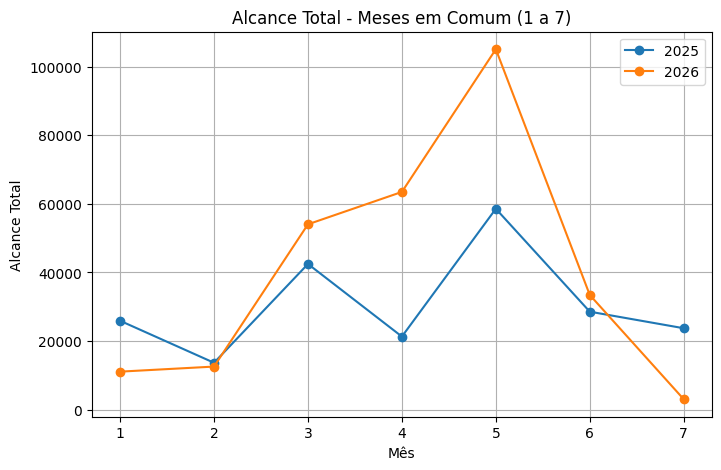

In [25]:

plt.figure(figsize=(8,5))

# Alcance Total
metricas_a25["alcance_total"].plot(label="2025", marker="o")
metricas_a26["alcance_total"].plot(label="2026", marker="o")

plt.title("Alcance Total - Meses em Comum (1 a 7)")
plt.xlabel("Mês")
plt.ylabel("Alcance Total")
plt.legend()
plt.grid(True)
plt.show()

2026 foi um ano melhor do que 2025 nos meses: 3, 4, 5, 6
2025 foi um ano melhor do que 2026 nos meses: 1, 2

O início de 2025 foi melhor que o de 2026 porém os próximos meses de 2026 tiveram uma grande melhora porém no mês 7 de 2026 teve um número muito abaixo

Grande queda do mês 5 para 6 em 2026


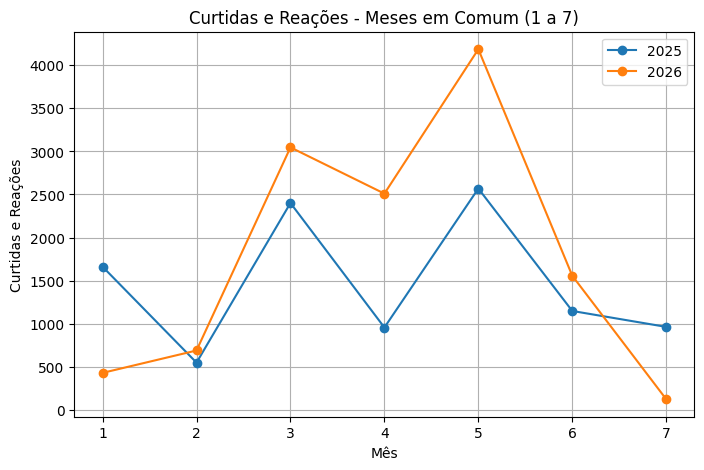

In [26]:

plt.figure(figsize=(8,5))

# Alcance Total
metricas_a25["curtidas_e_reacoes"].plot(label="2025", marker="o")
metricas_a26["curtidas_e_reacoes"].plot(label="2026", marker="o")

plt.title("Curtidas e Reações - Meses em Comum (1 a 7)")
plt.xlabel("Mês")
plt.ylabel("Curtidas e Reações")
plt.legend()
plt.grid(True)
plt.show()

2026 foi um ano melhor do que 2025 nos meses: 2, 3, 4, 5, 6
2025 foi um ano melhor do que 2026 nos meses: 1

O início de 2025 foi melhor que o de 2026 porém os próximos meses de 2026 tiveram uma grande melhora porém no mês 7 de 2026 teve um número muito abaixo

Grande queda do mês 5 para 6 em 2026

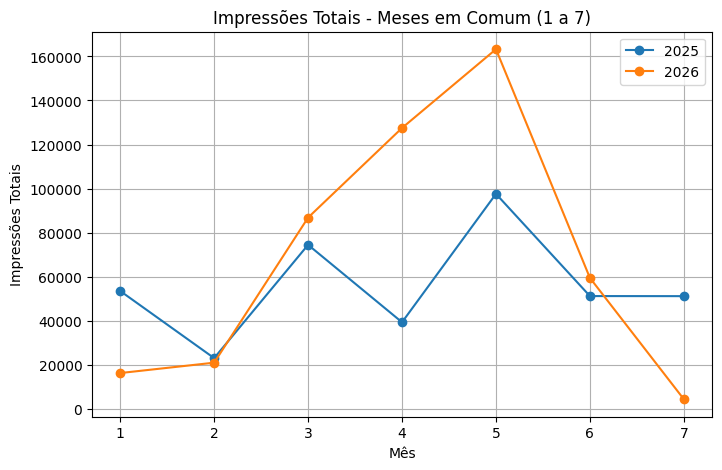

In [27]:

plt.figure(figsize=(8,5))

metricas_a25["impressoes_totais"].plot(label="2025", marker="o")
metricas_a26["impressoes_totais"].plot(label="2026", marker="o")

plt.title("Impressões Totais - Meses em Comum (1 a 7)")
plt.xlabel("Mês")
plt.ylabel("Impressões Totais")
plt.legend()
plt.grid(True)
plt.show()

2026 foi um ano melhor do que 2025 nos meses: 3, 4, 5, 6
2025 foi um ano melhor do que 2026 nos meses: 1, 2

O início de 2025 foi melhor que o de 2026 porém os próximos meses de 2026 tiveram uma grande melhora porém no mês 7 de 2026 teve um número muito abaixo por conta de não ter os dados completos do mês

Grande queda do mês 5 para 6 em 2026


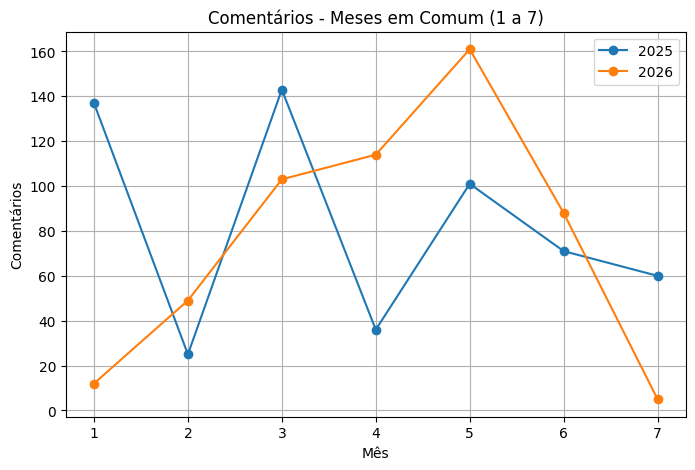

In [28]:

plt.figure(figsize=(8,5))
metricas_a25["comentarios"].plot(label="2025", marker="o")
metricas_a26["comentarios"].plot(label="2026", marker="o")

plt.title("Comentários - Meses em Comum (1 a 7)")
plt.xlabel("Mês")
plt.ylabel("Comentários")
plt.legend()
plt.grid(True)
plt.show()

2025 tem um início de ano com altos e baixos extremos

2026 teve crescimento contínuo, até chegar no mês 6 onde houve queda


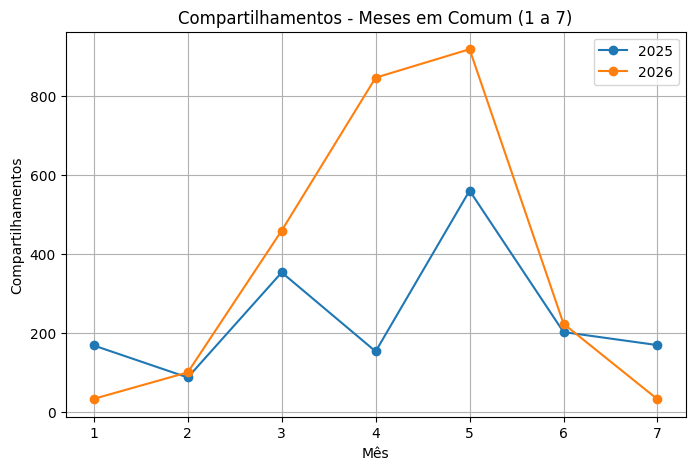

In [29]:

plt.figure(figsize=(8,5))
metricas_a25["compartilhamentos"].plot(label="2025", marker="o")
metricas_a26["compartilhamentos"].plot(label="2026", marker="o")

plt.title("Compartilhamentos - Meses em Comum (1 a 7)")
plt.xlabel("Mês")
plt.ylabel("Compartilhamentos")
plt.legend()
plt.grid(True)
plt.show()

2026 apresentou maior número de compartilhamentos que 2025 nos meses 3, 4 e 5.

O mês 5 de 2026 teve o maior número de compartilhamentos, seguido por uma grande queda no mês 6.

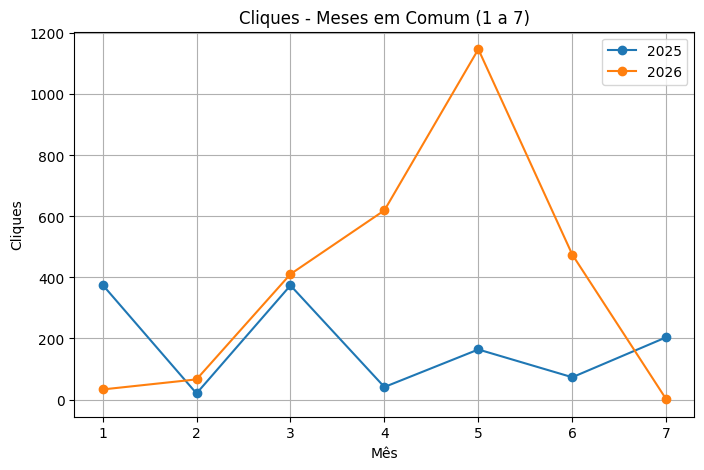

In [30]:

plt.figure(figsize=(8,5))
metricas_a25["cliques"].plot(label="2025", marker="o")
metricas_a26["cliques"].plot(label="2026", marker="o")

plt.title("Cliques - Meses em Comum (1 a 7)")
plt.xlabel("Mês")
plt.ylabel("Cliques")
plt.legend()
plt.grid(True)
plt.show()

2025 teve números de cliques muito menores que 2026, tendo apenas o mês 1 contendo mais cliques do que 2026

Mês 5 de 2026 muito melhor do que qualquer outro mês

Grande queda no mês 6 de 2026

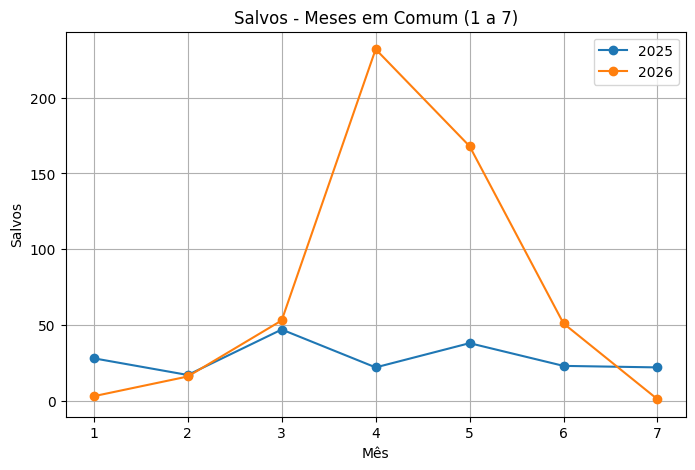

In [31]:

plt.figure(figsize=(8,5))
metricas_a25["salvos"].plot(label="2025", marker="o")
metricas_a26["salvos"].plot(label="2026", marker="o")

plt.title("Salvos - Meses em Comum (1 a 7)")
plt.xlabel("Mês")
plt.ylabel("Salvos")
plt.legend()
plt.grid(True)
plt.show()

Mês 4 foi o melhor mês em posts salvos, tendo uma queda no mês 5 seguida de mais uma no mês 6

2026 melhor na maioria dos meses em comparação a 2025

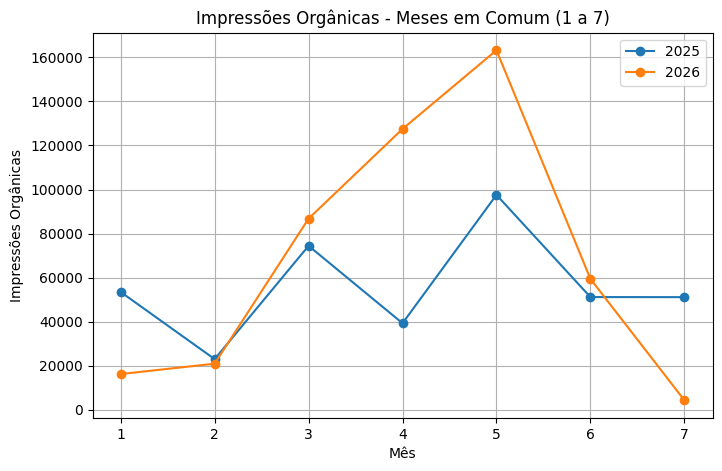

In [32]:

plt.figure(figsize=(8,5))
metricas_a25["impressoes_organicas"].plot(label="2025", marker="o")
metricas_a26["impressoes_organicas"].plot(label="2026", marker="o")

plt.title("Impressões Orgânicas - Meses em Comum (1 a 7)")
plt.xlabel("Mês")
plt.ylabel("Impressões Orgânicas")
plt.legend()
plt.grid(True)
plt.show()

2026 teve crescimento crescente até ter uma queda no mês 6

2025 com muitos altos e baixos com números menores

Mês 5 sendo o melhor nos 2 anos

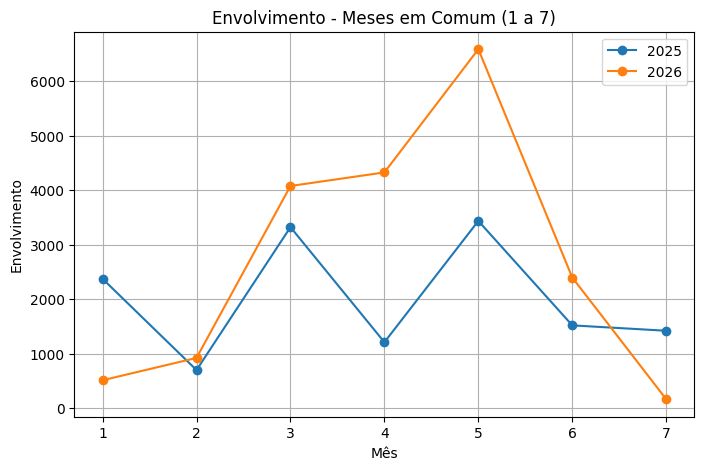

In [33]:

plt.figure(figsize=(8,5))
metricas_a25["envolvimento"].plot(label="2025", marker="o")
metricas_a26["envolvimento"].plot(label="2026", marker="o")

plt.title("Envolvimento - Meses em Comum (1 a 7)")
plt.xlabel("Mês")
plt.ylabel("Envolvimento")
plt.legend()
plt.grid(True)
plt.show()

Maioria dos meses foram melhores em 2026 principalmente 4 e 5

Mês 6 com queda nos 2 anos

-----------------------------------------------------------------

**Análise Geral por ano**

O início de 2025 foi melhor na maioria das métricas que o de 2026, porém os resultados de 2026 apresentaram uma evolução maior nos meses seguintes, principalmente entre os meses 3 e 5.

2026 apresentou seu melhor desempenho no mês 5, que foi o período de maior resultado geral entre os dois anos em diversas métricas.

Após o pico do mês 5, houve uma queda significativa no mês 6 de 2026, porém os resultados ainda permaneceram superiores aos de 2025 em várias métricas.

2025 apresentou maiores oscilações ao longo dos meses, com períodos de crescimento e queda, enquanto 2026 apresentou uma evolução mais forte até o mês 5.

De modo geral, 2026 apresentou uma melhora significativa em relação ao início do ano e teve os melhores resultados nos meses 3, 4 e 5, enquanto 2025 apresentou um desempenho mais equilibrado, mas com menor crescimento ao longo do período.

Mesmo sendo diferentes os 2 anos tiveram um comportamento parecido,os dois tinham um mês de queda e depois um mês melhor. O tamanho da melhora e piora que muda de um para o outro.

 Em 2025, os resultados eram equilibrados, mas cheios de altos e baixos, sem sair muito do lugar. Já em 2026, o ano começou devagar, mas engrenou uma subida forte entre março e maio, batendo todos os recordes históricos no mês 5. Mesmo com uma queda logo depois, em junho, o ritmo de 2026 continuou muito mais alto e eficiente do que o do ano anterior, mostrando que a operação subiu de nível.

Visualização do mês 7 sendo incompleto

In [34]:


ultimo_mes = df[(df["ano"] == 2026) & (df["mes"] == 7)]

ultimo_mes["dia"] = ultimo_mes["data_hora_criacao"].dt.date

print(ultimo_mes["dia"].value_counts())

dia
2026-07-03    2
2026-07-02    2
Name: count, dtype: int64


C:\Users\Davi Kunzler Loser\AppData\Local\Temp\ipykernel_15788\1580291427.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ultimo_mes["dia"] = ultimo_mes["data_hora_criacao"].dt.date


Existe um número tão baixo no mês 7 de 2026 porque ele está com os dados incompletos

Então mês 7 vai ser desconsiderado

**Métricas de 2025 e 2026 desconsiderando o mês 7 por falta de dados do ano 2026**

In [35]:
new_a25 = df[df['ano'] == 2025]
new_mes_comum = new_a25[new_a25['mes'].isin([1,2,3,4,5,6])]
new_metricas_a25 = new_mes_comum.groupby('mes')[[    
    "alcance_total",
    "curtidas_e_reacoes",
    "comentarios",
    "compartilhamentos",
    "cliques",
    "salvos",
    "impressoes_organicas",
    "impressoes_totais",
    "envolvimento"]].sum()
new_metricas_a25

,alcance_total,curtidas_e_reacoes,comentarios,compartilhamentos,cliques,salvos,impressoes_organicas,impressoes_totais,envolvimento
mes,,,,,,,,,
1,25902,1661,137,169,376,28,53462,53467,2371
2,13655,547,25,88,20,17,22975,22980,697
3,42462,2401,143,354,374,47,74434,74435,3319
4,21295,955,36,154,41,22,39274,39276,1208
5,58558,2569,101,561,164,38,97570,97577,3433
6,28551,1147,71,203,73,23,51162,51165,1517


In [36]:
new_a25 = df[df['ano'] == 2025]
new_mes_comum = new_a25[new_a25['mes'].isin([1,2,3,4,5,6])]
taxa_engajamento25 = new_mes_comum.groupby('mes')[[    
    'taxa_de_engajamento'
]].mean()
taxa_engajamento25

,taxa_de_engajamento
mes,
1,2.184107
2,0.350388
3,1.054283
4,0.284564
5,0.066505
6,0.060904


In [37]:
new_a26 = df[df['ano'] == 2026]
new_mes_comum = new_a26[new_a26['mes'].isin([1,2,3,4,5,6])]
new_metricas_a26 = new_mes_comum.groupby('mes')[[    
    "alcance_total",
    "curtidas_e_reacoes",
    "comentarios",
    "compartilhamentos",
    "cliques",
    "salvos",
    "impressoes_organicas",
    "impressoes_totais",
    "envolvimento"]].sum()
new_metricas_a26

,alcance_total,curtidas_e_reacoes,comentarios,compartilhamentos,cliques,salvos,impressoes_organicas,impressoes_totais,envolvimento
mes,,,,,,,,,
1,11067,428,12,34,33,3,16202,16203,510
2,12543,688,49,101,66,16,20906,20911,920
3,54032,3047,103,460,411,53,86791,86798,4074
4,63472,2510,114,847,620,232,127506,127507,4323
5,105085,4187,161,919,1148,168,163268,163275,6583
6,33422,1556,88,224,475,51,59421,59422,2394


In [38]:
new_a26 = df[df['ano'] == 2026]
new_mes_comum = new_a26[new_a26['mes'].isin([1,2,3,4,5,6])]
taxa_engajamento26 = new_mes_comum.groupby('mes')[[    
    'taxa_de_engajamento'
]].mean()
taxa_engajamento26

,taxa_de_engajamento
mes,
1,0.044384
2,0.062282
3,0.066526
4,0.065892
5,0.110418
6,0.061719


## Presença de outliers

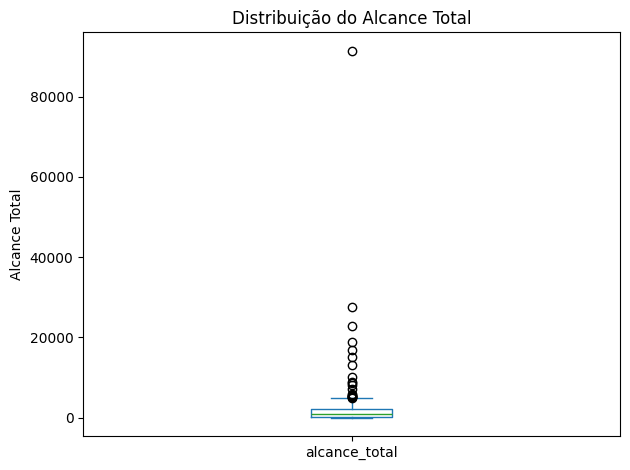

In [39]:
df['alcance_total'].plot.box()

plt.title("Distribuição do Alcance Total")
plt.ylabel("Alcance Total")

plt.tight_layout()
plt.show()

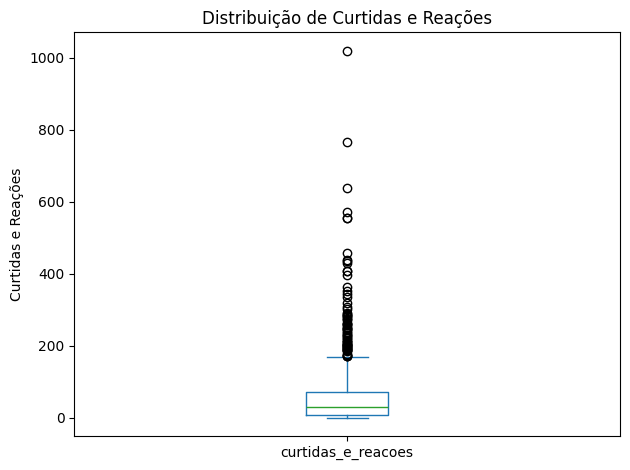

In [40]:
df['curtidas_e_reacoes'].plot.box()

plt.title("Distribuição de Curtidas e Reações")
plt.ylabel("Curtidas e Reações")

plt.tight_layout()
plt.show()

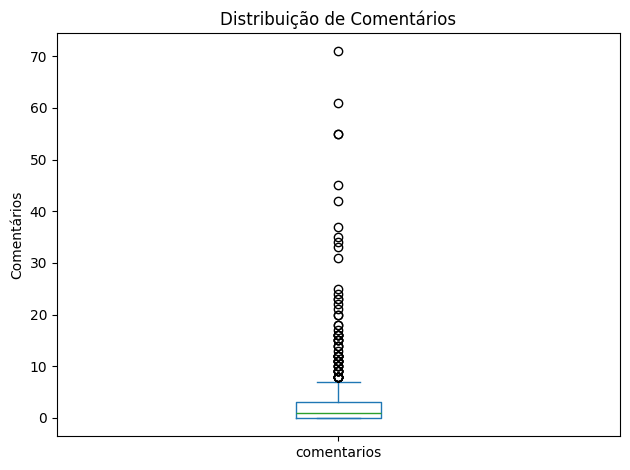

In [41]:
df['comentarios'].plot.box()

plt.title("Distribuição de Comentários")
plt.ylabel("Comentários")

plt.tight_layout()
plt.show()

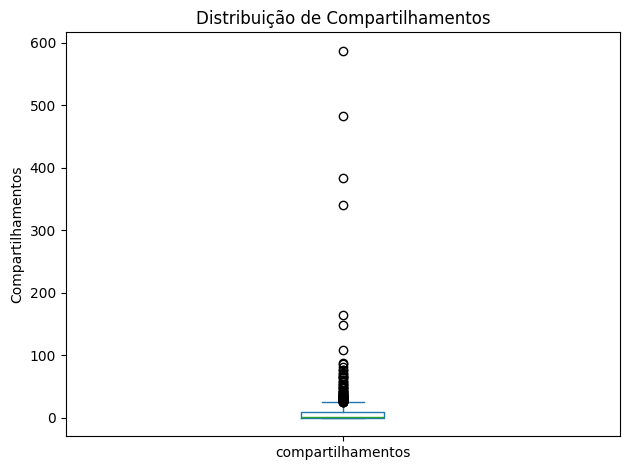

In [42]:
df['compartilhamentos'].plot.box()

plt.title("Distribuição de Compartilhamentos")
plt.ylabel("Compartilhamentos")

plt.tight_layout()
plt.show()

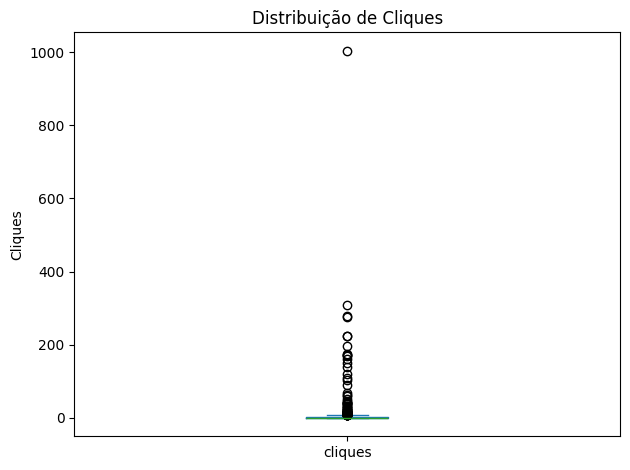

In [43]:
df['cliques'].plot.box()

plt.title("Distribuição de Cliques")
plt.ylabel("Cliques")

plt.tight_layout()
plt.show()

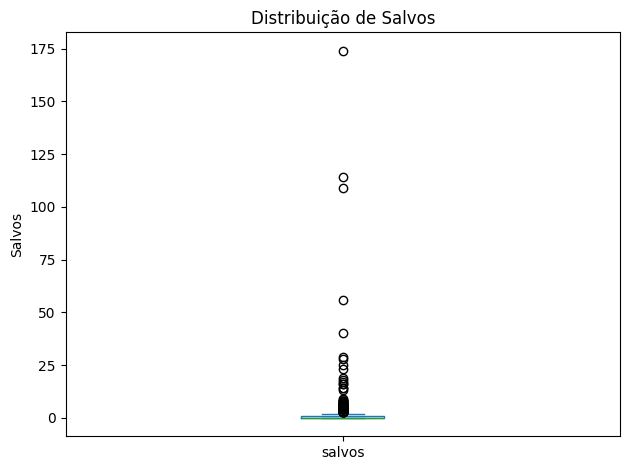

In [44]:
df['salvos'].plot.box()

plt.title("Distribuição de Salvos")
plt.ylabel("Salvos")

plt.tight_layout()
plt.show()

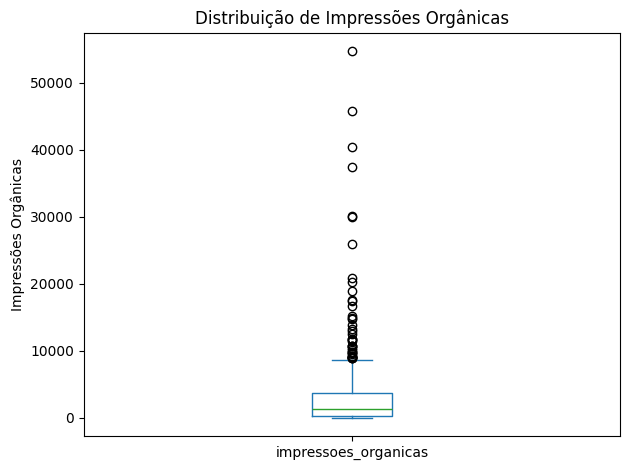

In [45]:
df['impressoes_organicas'].plot.box()

plt.title("Distribuição de Impressões Orgânicas")
plt.ylabel("Impressões Orgânicas")

plt.tight_layout()
plt.show()

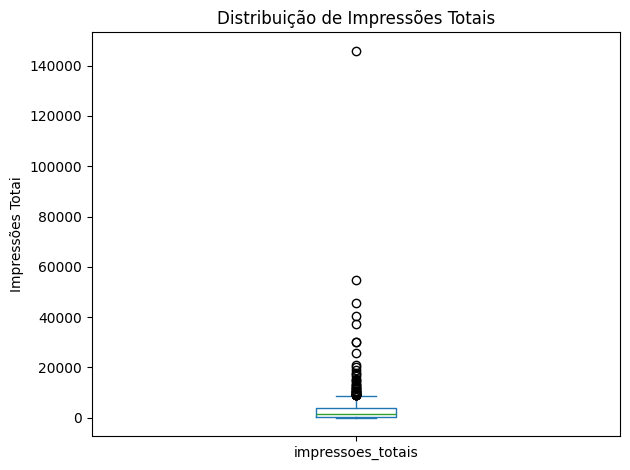

In [46]:
df['impressoes_totais'].plot.box()

plt.title("Distribuição de Impressões Totais")
plt.ylabel("Impressões Totai")

plt.tight_layout()
plt.show()

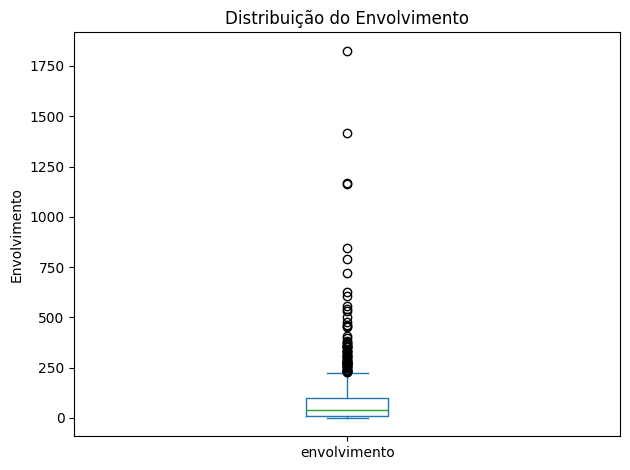

In [47]:
df['envolvimento'].plot.box()

plt.title("Distribuição do Envolvimento")
plt.ylabel("Envolvimento")

plt.tight_layout()
plt.show()

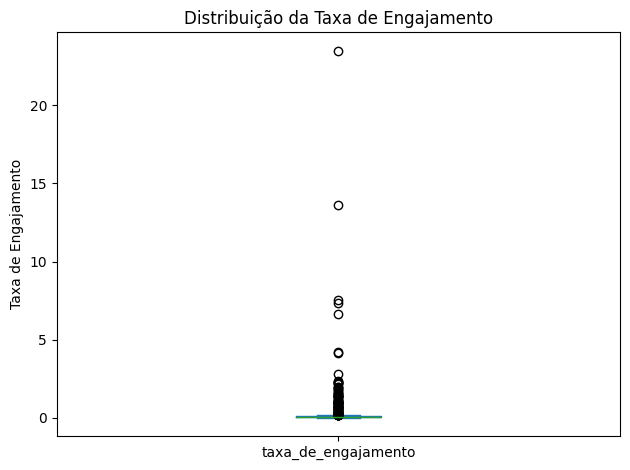

In [48]:
df['taxa_de_engajamento'].plot.box()

plt.title("Distribuição da Taxa de Engajamento")
plt.ylabel("Taxa de Engajamento")

plt.tight_layout()
plt.show()

**Análise geral dos gráficos boxplot**

As variáveis analisadas apresentam muitos outliers, principalmente acima do limite superior, indicando assimetria positiva e alta dispersão. Por isso, a mediana é mais adequada que a média para representar os valores centrais. Os outliers não devem ser removidos automaticamente, pois podem representar desempenhos excepcionalmente altos.

O comportamento é semelhante entre as variáveis, com destaque para o alcance orgânico, que apresenta concentração próxima à mediana devido à substituição dos valores nulos pela mediana durante a limpeza dos dados.


**Taxa de variação entre os meses em comum de 2025 e 2026**

In [49]:
taxa_de_variacao = ((new_metricas_a26 - new_metricas_a25) / new_metricas_a25)
taxa_de_variacao.round(2)

,alcance_total,curtidas_e_reacoes,comentarios,compartilhamentos,cliques,salvos,impressoes_organicas,impressoes_totais,envolvimento
mes,,,,,,,,,
1,-0.57,-0.74,-0.91,-0.80,-0.91,-0.89,-0.70,-0.70,-0.78
2,-0.08,0.26,0.96,0.15,2.30,-0.06,-0.09,-0.09,0.32
3,0.27,0.27,-0.28,0.30,0.10,0.13,0.17,0.17,0.23
4,1.98,1.63,2.17,4.50,14.12,9.55,2.25,2.25,2.58
5,0.79,0.63,0.59,0.64,6.00,3.42,0.67,0.67,0.92
6,0.17,0.36,0.24,0.10,5.51,1.22,0.16,0.16,0.58


As taxas de variação no mês 4 ficaram extremamente altas

Taxa de variação aplicada aos meses em comum de 2026

In [50]:
taxa_variacao_engajamento = ((taxa_engajamento26 - taxa_engajamento25) / taxa_engajamento25)
taxa_variacao_engajamento.round(2)

,taxa_de_engajamento
mes,
1,-0.98
2,-0.82
3,-0.94
4,-0.77
5,0.66
6,0.01


In [51]:
valor_final = new_metricas_a26 * (1 + taxa_de_variacao)
valor_final.round(2)

,alcance_total,curtidas_e_reacoes,comentarios,compartilhamentos,cliques,salvos,impressoes_organicas,impressoes_totais,envolvimento
mes,,,,,,,,,
1,4728.53,110.29,1.05,6.84,2.90,0.32,4910.12,4910.27,109.70
2,11521.56,865.35,96.04,115.92,217.80,15.06,19023.32,19028.28,1214.35
3,68754.58,3866.81,74.19,597.74,451.66,59.77,101199.42,101214.39,5000.75
4,189185.01,6596.96,361.00,4658.50,9375.61,2446.55,413957.84,413943.25,15470.47
5,188579.82,6824.04,256.64,1505.46,8036.00,742.74,273203.24,273207.06,12623.33
6,39124.03,2110.84,109.07,247.17,3090.75,113.09,69013.24,69011.51,3778.01


**Gráficos comparando as métricas 2026 e 2027 com a média**

Alcance Total (2026-2027)

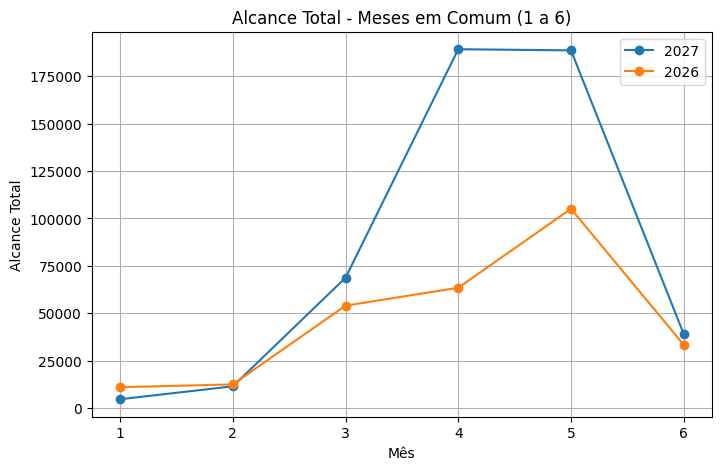

In [52]:

plt.figure(figsize=(8,5))

valor_final["alcance_total"].plot(label="2027", marker="o")
new_metricas_a26["alcance_total"].plot(label="2026", marker="o")

plt.title("Alcance Total - Meses em Comum (1 a 6)")
plt.xlabel("Mês")
plt.ylabel("Alcance Total")
plt.legend()
plt.grid(True)
plt.show()

Curtidas e Reações (2026-2027)

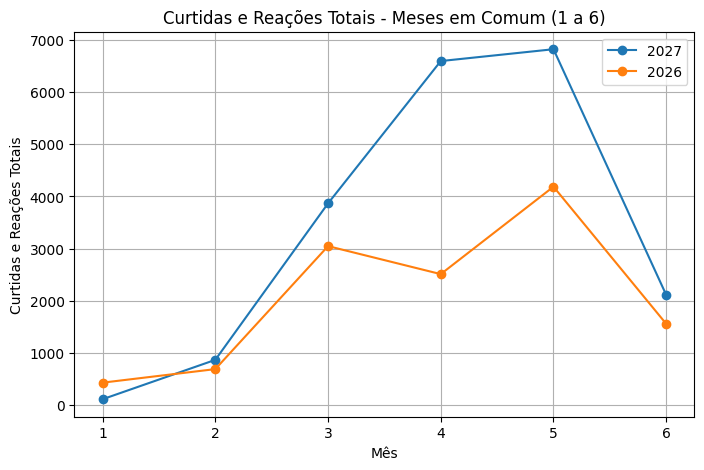

In [53]:

plt.figure(figsize=(8,5))

valor_final["curtidas_e_reacoes"].plot(label="2027", marker="o")
new_metricas_a26["curtidas_e_reacoes"].plot(label="2026", marker="o")

plt.title("Curtidas e Reações Totais - Meses em Comum (1 a 6)")
plt.xlabel("Mês")
plt.ylabel("Curtidas e Reações Totais")
plt.legend()
plt.grid(True)
plt.show()

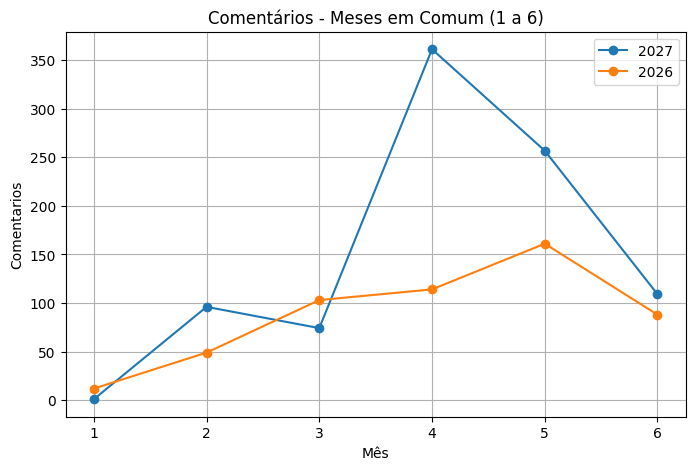

In [54]:

plt.figure(figsize=(8,5))

valor_final["comentarios"].plot(label="2027", marker="o")
new_metricas_a26["comentarios"].plot(label="2026", marker="o")

plt.title("Comentários - Meses em Comum (1 a 6)")
plt.xlabel("Mês")
plt.ylabel("Comentarios")
plt.legend()
plt.grid(True)
plt.show()

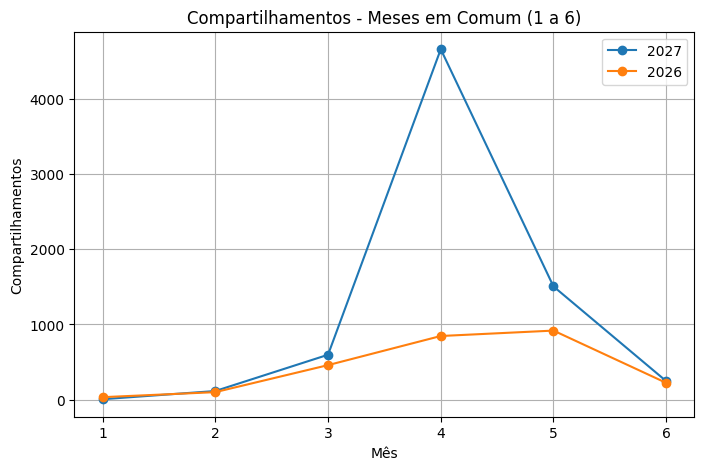

In [55]:

plt.figure(figsize=(8,5))

valor_final["compartilhamentos"].plot(label="2027", marker="o")
new_metricas_a26["compartilhamentos"].plot(label="2026", marker="o")

plt.title("Compartilhamentos - Meses em Comum (1 a 6)")
plt.xlabel("Mês")
plt.ylabel("Compartilhamentos")
plt.legend()
plt.grid(True)
plt.show()

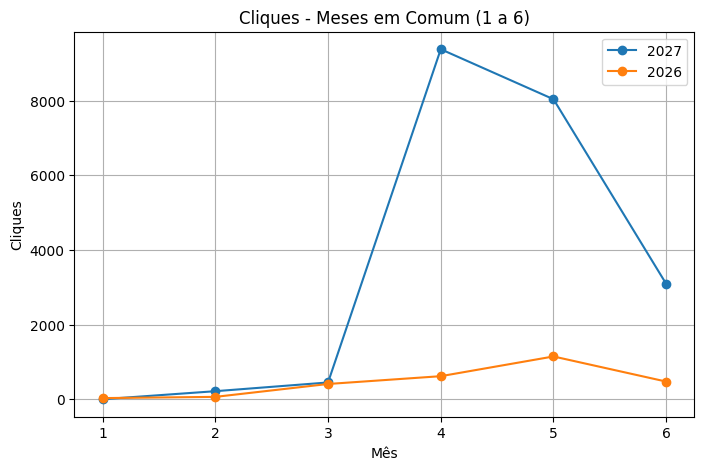

In [56]:

plt.figure(figsize=(8,5))

valor_final["cliques"].plot(label="2027", marker="o")
new_metricas_a26["cliques"].plot(label="2026", marker="o")

plt.title("Cliques - Meses em Comum (1 a 6)")
plt.xlabel("Mês")
plt.ylabel("Cliques")
plt.legend()
plt.grid(True)
plt.show()

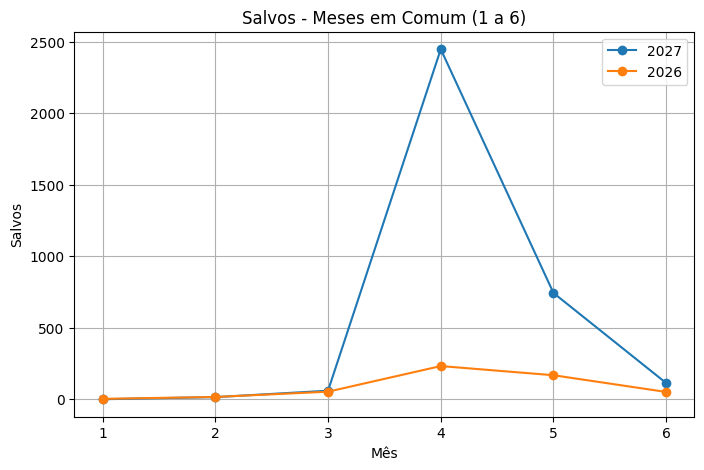

In [57]:

plt.figure(figsize=(8,5))

valor_final["salvos"].plot(label="2027", marker="o")
new_metricas_a26["salvos"].plot(label="2026", marker="o")

plt.title("Salvos - Meses em Comum (1 a 6)")
plt.xlabel("Mês")
plt.ylabel("Salvos")
plt.legend()
plt.grid(True)
plt.show()

Impressões Totais (2026-2027)

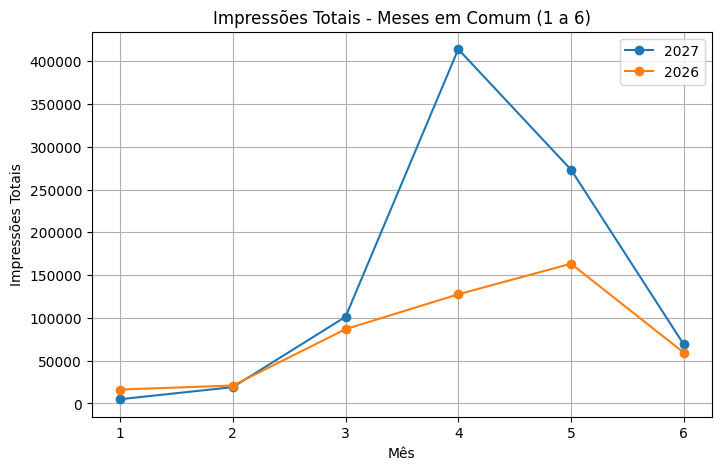

In [58]:

plt.figure(figsize=(8,5))

valor_final["impressoes_totais"].plot(label="2027", marker="o")
new_metricas_a26["impressoes_totais"].plot(label="2026", marker="o")

plt.title("Impressões Totais - Meses em Comum (1 a 6)")
plt.xlabel("Mês")
plt.ylabel("Impressões Totais")
plt.legend()
plt.grid(True)
plt.show()

-----------------------

## Posts com maiorer números das métricas

In [59]:
top_posts = df.sort_values(
    "alcance_total",
    ascending=False
).head(10)

top_posts[[
    "alcance_total",
    "curtidas_e_reacoes",
    "comentarios",
    "compartilhamentos",
    "cliques",
    "salvos",
    "impressoes_organicas",
    "impressoes_totais",
    "envolvimento"
]]

,alcance_total,curtidas_e_reacoes,comentarios,compartilhamentos,cliques,salvos,impressoes_organicas,impressoes_totais,envolvimento
321,91421,4,0,0,150,0,197,145970,154
79,27544,122,5,32,1004,0,37392,37392,1163
97,22812,1020,45,587,0,174,54751,54751,1826
241,18752,766,55,483,0,114,45796,45796,1418
78,16902,639,34,384,0,109,30123,30123,1166
459,15043,430,9,148,0,18,20224,20224,605
267,13085,435,16,340,0,56,40405,40405,847
115,10248,238,8,16,0,7,14963,14963,269
569,8828,571,35,108,0,8,15253,15253,722
184,8727,554,42,164,0,28,13868,13868,788


In [60]:
top_posts = df.sort_values(
    "curtidas_e_reacoes",
    ascending=False
).head(10)

top_posts[[
    "alcance_total",
    "curtidas_e_reacoes",
    "comentarios",
    "compartilhamentos",
    "cliques",
    "salvos",
    "impressoes_organicas",
    "impressoes_totais",
    "envolvimento"
]]

,alcance_total,curtidas_e_reacoes,comentarios,compartilhamentos,cliques,salvos,impressoes_organicas,impressoes_totais,envolvimento
97,22812,1020,45,587,0,174,54751,54751,1826
241,18752,766,55,483,0,114,45796,45796,1418
78,16902,639,34,384,0,109,30123,30123,1166
569,8828,571,35,108,0,8,15253,15253,722
187,5197,555,15,38,0,19,8922,8922,627
184,8727,554,42,164,0,28,13868,13868,788
180,4251,459,14,35,0,25,7630,7630,533
136,4235,438,13,88,0,16,7474,7474,555
267,13085,435,16,340,0,56,40405,40405,847
459,15043,430,9,148,0,18,20224,20224,605


In [61]:
top_posts = df.sort_values(
    "compartilhamentos",
    ascending=False
).head(10)

top_posts[[
    "alcance_total",
    "curtidas_e_reacoes",
    "comentarios",
    "compartilhamentos",
    "cliques",
    "salvos",
    "impressoes_organicas",
    "impressoes_totais",
    "envolvimento"
]]

,alcance_total,curtidas_e_reacoes,comentarios,compartilhamentos,cliques,salvos,impressoes_organicas,impressoes_totais,envolvimento
97,22812,1020,45,587,0,174,54751,54751,1826
241,18752,766,55,483,0,114,45796,45796,1418
78,16902,639,34,384,0,109,30123,30123,1166
267,13085,435,16,340,0,56,40405,40405,847
184,8727,554,42,164,0,28,13868,13868,788
459,15043,430,9,148,0,18,20224,20224,605
569,8828,571,35,108,0,8,15253,15253,722
136,4235,438,13,88,0,16,7474,7474,555
530,3450,116,4,86,0,3,4592,4592,209
509,4645,364,22,81,0,8,8247,8247,475


In [62]:
top_posts = df.sort_values(
    "envolvimento",
    ascending=False
).head(10)

top_posts[[
    "alcance_total",
    "curtidas_e_reacoes",
    "comentarios",
    "compartilhamentos",
    "cliques",
    "salvos",
    "impressoes_organicas",
    "impressoes_totais",
    "envolvimento"
]]

,alcance_total,curtidas_e_reacoes,comentarios,compartilhamentos,cliques,salvos,impressoes_organicas,impressoes_totais,envolvimento
97,22812,1020,45,587,0,174,54751,54751,1826
241,18752,766,55,483,0,114,45796,45796,1418
78,16902,639,34,384,0,109,30123,30123,1166
79,27544,122,5,32,1004,0,37392,37392,1163
267,13085,435,16,340,0,56,40405,40405,847
184,8727,554,42,164,0,28,13868,13868,788
569,8828,571,35,108,0,8,15253,15253,722
187,5197,555,15,38,0,19,8922,8922,627
459,15043,430,9,148,0,18,20224,20224,605
136,4235,438,13,88,0,16,7474,7474,555


A ordenação dos 10 principais posts mostra que alcance e engajamento nem sempre caminham juntos. O post com maior alcance da base (91.421 pessoas) registrou apenas 4 curtidas e quase nenhuma outra interação, possivelmente devido a rede social ou ao tipo de post. Em contrapartida, a publicação que liderou em curtidas (1.020), compartilhamentos (587) e comentários (45) também gerou o segundo maior alcance (22.812) e o maior envolvimento total (1.826). Esse contraste confirma a alta variabilidade indicada pelos boxplots e reforça que avaliar o sucesso de uma publicação exige olhar além de uma única métrica isolada.

## Análise pelo tipo de post

In [63]:
df["tipo"].value_counts()

tipo
reels         288
imagem         99
carrossel      97
galeria        95
vídeo           4
Name: count, dtype: int64

Número muito maior de reels comparado aos outros

Vriáveis imagem, carrossel e galeria com quantidades semelhantes de posts

Quantidade de posts vídeo baixa

In [64]:

separado_tipo = df.groupby('tipo')[[
    "alcance_total",
    "curtidas_e_reacoes",
    "comentarios",
    "compartilhamentos",
    "cliques",
    "salvos",
    "impressoes_organicas",
    "impressoes_totais",
    "envolvimento"
    ]].sum()
separado_tipo

,alcance_total,curtidas_e_reacoes,comentarios,compartilhamentos,cliques,salvos,impressoes_organicas,impressoes_totais,envolvimento
tipo,,,,,,,,,
carrossel,231234,10019,363,2560,0,555,737046,737046,13497
galeria,30190,1186,108,106,2631,0,65743,65743,4031
imagem,161387,4635,189,966,1556,232,336533,336533,7578
reels,510081,22582,1362,3448,1567,484,640067,785992,29443
vídeo,420,34,2,3,7,0,788,789,46


In [65]:
media_tipo_post = df.groupby("tipo")[[    
    "alcance_total",
    "curtidas_e_reacoes",
    "comentarios",
    "compartilhamentos",
    "cliques",
    "salvos",
    "impressoes_organicas",
    "impressoes_totais",
    "envolvimento"]].mean()
media_tipo_post

,alcance_total,curtidas_e_reacoes,comentarios,compartilhamentos,cliques,salvos,impressoes_organicas,impressoes_totais,envolvimento
tipo,,,,,,,,,
carrossel,2383.855670,103.288660,3.742268,26.391753,0.000000,5.721649,7598.412371,7598.412371,139.144330
galeria,317.789474,12.484211,1.136842,1.115789,27.694737,0.000000,692.031579,692.031579,42.431579
imagem,1630.171717,46.818182,1.909091,9.757576,15.717172,2.343434,3399.323232,3399.323232,76.545455
reels,1771.114583,78.409722,4.729167,11.972222,5.440972,1.680556,2222.454861,2729.138889,102.232639
vídeo,105.000000,8.500000,0.500000,0.750000,1.750000,0.000000,197.000000,197.250000,11.500000


**Reels**

Os Reels foram o tipo de publicação mais utilizado, com 288 publicações, representando quase metade da base analisada. Apesar de apresentarem os maiores valores totais em diversas métricas, a média por publicação mostra um desempenho de 1.771,11 de alcance total, 78,41 curtidas e reações, 4,73 comentários, 11,97 compartilhamentos, 5,44 cliques, 1,68 salvos, 2.729,14 impressões totais e 102,23 de envolvimento. Dessa forma, os Reels apresentam um desempenho médio elevado e consistente, além de contribuírem significativamente para os resultados totais devido ao grande número de publicações.

**Carrossel**

Os carrosséis tiveram 97 publicações e apresentaram o melhor desempenho médio geral entre os formatos analisados. Cada publicação alcançou, em média, 2.383,86 pessoas, gerou 103,29 curtidas e reações, 3,74 comentários, 26,39 compartilhamentos, 5,72 salvos, 7.598,41 impressões e 139,14 de envolvimento. Esses resultados são superiores aos dos Reels na maioria das principais métricas, especialmente em alcance, curtidas, compartilhamentos, impressões e envolvimento. O principal ponto negativo é a média de 0 cliques, indicando que, nos dados analisados, os carrosséis se destacam mais pela geração de interação e alcance do que pela geração de cliques.

**Imagem**

As imagens tiveram 99 publicações e apresentaram um desempenho médio intermediário. Cada publicação obteve aproximadamente 1.630,17 de alcance total, 46,82 curtidas e reações, 1,91 comentários, 9,76 compartilhamentos, 15,72 cliques, 2,34 salvos, 3.399,32 impressões totais e 76,55 de envolvimento. O principal destaque está nos cliques, com uma média de 15,72 por publicação, valor superior ao dos Reels e inferior apenas ao das galerias. Dessa forma, as imagens apresentam um desempenho equilibrado, mas não lideram nas métricas de alcance e interação, ficando abaixo dos carrosséis e Reels.

**Galeria**

As galerias tiveram 95 publicações e apresentaram um desempenho médio mais baixo nas métricas relacionadas a alcance e interação. Cada publicação alcançou, em média, 317,79 pessoas, gerou 12,48 curtidas e reações, 1,14 comentários, 1,12 compartilhamentos, 27,69 cliques, 692,03 impressões e 42,43 de envolvimento. O grande destaque está nos cliques, sendo o maior valor médio entre todos os formatos analisados. Portanto, apesar de apresentar baixo alcance e baixo envolvimento, a galeria demonstra uma característica específica de geração de cliques, podendo ser um formato mais direcionado a essa finalidade.

**Vídeo**

Os vídeos tiveram apenas 4 publicações, representando uma parcela muito pequena da base. A média foi de 105 de alcance total, 8,50 curtidas e reações, 0,50 comentários, 0,75 compartilhamentos, 1,75 cliques, 197,25 impressões totais e 11,50 de envolvimento por publicação. Esses são os menores valores médios entre os formatos analisados. Entretanto, devido ao número muito reduzido de publicações, o resultado deve ser interpretado com cautela, pois quatro observações não são suficientes para estabelecer uma comparação tão confiável quanto a realizada para os demais formatos.

**Conclusão geral**

A análise das médias mostra que o carrossel apresenta o melhor desempenho médio geral, principalmente por possuir os maiores valores de alcance, curtidas, compartilhamentos, impressões e envolvimento por publicação. Os Reels, por outro lado, apresentam um desempenho médio elevado e possuem grande importância no resultado total devido à quantidade muito maior de publicações. As imagens apresentam desempenho intermediário e se destacam pela quantidade média de cliques, enquanto as galerias possuem o maior número médio de cliques, mas baixo desempenho nas demais métricas. Já os vídeos apresentam os menores resultados médios, embora a pequena quantidade de publicações impeça uma conclusão definitiva sobre seu desempenho.

## Análise por Rede Social

In [66]:
df['rede_social'].value_counts()

rede_social
Instagram    292
Facebook     291
Name: count, dtype: int64

In [67]:

separado_rede_social = df.groupby('rede_social')[[
    "alcance_total",
    "curtidas_e_reacoes",
    "comentarios",
    "compartilhamentos",
    "cliques",
    "salvos",
    "impressoes_organicas",
    "impressoes_totais",
    "envolvimento"
    ]].sum()
separado_rede_social

,alcance_total,curtidas_e_reacoes,comentarios,compartilhamentos,cliques,salvos,impressoes_organicas,impressoes_totais,envolvimento
rede_social,,,,,,,,,
Facebook,205410,3434,321,314,5761,0,197457,343383,9830
Instagram,727902,35022,1703,6769,0,1271,1582720,1582720,44765


In [68]:
media_rede_social = df.groupby("rede_social")[[    
    "alcance_total",
    "curtidas_e_reacoes",
    "comentarios",
    "compartilhamentos",
    "cliques",
    "salvos",
    "impressoes_organicas",
    "impressoes_totais",
    "envolvimento"]].mean()
media_rede_social

,alcance_total,curtidas_e_reacoes,comentarios,compartilhamentos,cliques,salvos,impressoes_organicas,impressoes_totais,envolvimento
rede_social,,,,,,,,,
Facebook,705.876289,11.800687,1.103093,1.079038,19.797251,0.00000,678.546392,1180.010309,33.780069
Instagram,2492.815068,119.938356,5.832192,23.181507,0.000000,4.35274,5420.273973,5420.273973,153.304795


Número de posts entre as 2 redes sociais foi parecido, 292 pelo Instagram e 291 pelo Facebook.
 
Mesmo com números semelhantes em posts, o Instagram foi superior na maioria das métricas.

Os posts pelo Instagram não tiveram nenhum clique, pode ser que o tipo de post tenha afetado isso.

Os posts pelo Facebook não tiveram nenhum salvamento, pode ter sido afetado pelo tipo do post, ou talvez não tenha a funcionalidade de salvar no Facebook.

In [69]:

metricas_mes = df.groupby(['rede_social' ,'tipo'])[[    
    "alcance_total",
    "curtidas_e_reacoes",
    "comentarios",
    "compartilhamentos",
    "cliques",
    "salvos",
    "impressoes_organicas",
    "impressoes_totais",
    "envolvimento"]].sum()
metricas_ordenadas = metricas_mes.sort_values(by='envolvimento', ascending=False)
metricas_ordenadas


alcance_total  curtidas_e_reacoes  comentarios  \
rede_social tipo                                                         
Instagram   reels              382792               21080         1215   
            carrossel          231234               10019          363   
            imagem             113876                3923          125   
Facebook    galeria             30190                1186          108   
            reels              127289                1502          147   
            imagem              47511                 712           64   
            vídeo                 420                  34            2   

                        compartilhamentos  cliques  salvos  \
rede_social tipo                                             
Instagram   reels                    3326        0     484   
            carrossel                2560        0     555   
            imagem                    883        0     232   
Facebook    galeria                   106     2631       0   
            reels                     122     1567       0   
            imagem                     83     1556       0   
            vídeo                       3        7       0   

                        impressoes_organicas  impressoes_totais  envolvimento  
rede_social tipo                                                               
Instagram   reels                     585070             585070         26105  
            carrossel                 737046             737046         13497  
            imagem                    260604             260604          5163  
Facebook    galeria                    65743              65743          4031  
            reels                      54997             200922          3338  
            imagem                     75929              75929          2415  
            vídeo                        788                789            46

In [70]:

metricas_mes = df.groupby(['rede_social' ,'tipo'])[[    
    "alcance_total",
    "curtidas_e_reacoes",
    "comentarios",
    "compartilhamentos",
    "cliques",
    "salvos",
    "impressoes_organicas",
    "impressoes_totais",
    "envolvimento"]].mean().round(2)
metricas_ordenadas = metricas_mes.sort_values(by='envolvimento', ascending=False)
metricas_ordenadas


alcance_total  curtidas_e_reacoes  comentarios  \
rede_social tipo                                                         
Instagram   reels             2639.94              145.38         8.38   
            carrossel         2383.86              103.29         3.74   
            imagem            2277.52               78.46         2.50   
Facebook    imagem             969.61               14.53         1.31   
            galeria            317.79               12.48         1.14   
            reels              890.13               10.50         1.03   
            vídeo              105.00                8.50         0.50   

                        compartilhamentos  cliques  salvos  \
rede_social tipo                                             
Instagram   reels                   22.94     0.00    3.34   
            carrossel               26.39     0.00    5.72   
            imagem                  17.66     0.00    4.64   
Facebook    imagem                   1.69    31.76    0.00   
            galeria                  1.12    27.69    0.00   
            reels                    0.85    10.96    0.00   
            vídeo                    0.75     1.75    0.00   

                        impressoes_organicas  impressoes_totais  envolvimento  
rede_social tipo                                                               
Instagram   reels                    4034.97            4034.97        180.03  
            carrossel                7598.41            7598.41        139.14  
            imagem                   5212.08            5212.08        103.26  
Facebook    imagem                   1549.57            1549.57         49.29  
            galeria                   692.03             692.03         42.43  
            reels                     384.59            1405.05         23.34  
            vídeo                     197.00             197.25         11.50

Os vídeos e os reels do Facebook são os únicos tipos que tiveram as impressões orgânicas sendo diferente das impressões totais.

Instagram teve números melhores na maioria das métricas, exceto os cliques. Talvez não tenham sido contabilizados ou não haja essa funcionalidade no Instagram. A mesma coisa de aplica aos posts salvos pelo Facebook que todos são 0.

Os resultados mostram que o tipo de publicação influencia diretamente o desempenho em cada rede social. No Instagram, os Reels se destacam pelo maior alcance, envolvimento, número de comentários, curtidas e reações, enquanto os carrosséis apresentam o maior número de impressões, compartilhamentos e salvamentos. Já no Facebook, as imagens apresentam os melhores resultados das métricas comparando aos outros tipos pelo Facebook.

Mediana da taxa de variação dos 6 meses em comum

In [71]:
taxa_mediana = taxa_de_variacao.median().round(2)
taxa_mediana

alcance_total           0.22
curtidas_e_reacoes      0.31
comentarios             0.42
compartilhamentos       0.22
cliques                 3.90
salvos                  0.67
impressoes_organicas    0.16
impressoes_totais       0.16
envolvimento            0.45
dtype: float64

In [72]:
taxa_engajamento_mediana = taxa_variacao_engajamento.median().round(2)
taxa_engajamento_mediana

taxa_de_engajamento   -0.8
dtype: float64

In [73]:
final_mediana = new_metricas_a26 * (taxa_mediana + 1)
final_mediana

,alcance_total,curtidas_e_reacoes,comentarios,compartilhamentos,cliques,salvos,impressoes_organicas,impressoes_totais,envolvimento
mes,,,,,,,,,
1,13501.74,560.68,17.04,41.48,161.7,5.01,18794.32,18795.48,739.50
2,15302.46,901.28,69.58,123.22,323.4,26.72,24250.96,24256.76,1334.00
3,65919.04,3991.57,146.26,561.20,2013.9,88.51,100677.56,100685.68,5907.30
4,77435.84,3288.10,161.88,1033.34,3038.0,387.44,147906.96,147908.12,6268.35
5,128203.70,5484.97,228.62,1121.18,5625.2,280.56,189390.88,189399.00,9545.35
6,40774.84,2038.36,124.96,273.28,2327.5,85.17,68928.36,68929.52,3471.30


In [74]:
engajamento_2027 = taxa_engajamento26 * (taxa_engajamento_mediana + 1)
engajamento_2027

,taxa_de_engajamento
mes,
1,0.008877
2,0.012456
3,0.013305
4,0.013178
5,0.022084
6,0.012344


## Outliers

Quantidade de outliers por métrica

In [75]:
variaveis = df.select_dtypes(include='number').columns

for coluna in variaveis:
    q1 = df[coluna].quantile(0.25)
    q3 = df[coluna].quantile(0.75)

    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    quantidade = (
        (df[coluna] < limite_inferior) |
        (df[coluna] > limite_superior)
    ).sum()

    print(f"{coluna}: {quantidade} outliers")

ano: 0 outliers
mes: 0 outliers
alcance_total: 20 outliers
curtidas_e_reacoes: 68 outliers
comentarios: 67 outliers
compartilhamentos: 70 outliers
cliques: 70 outliers
salvos: 104 outliers
impressoes_organicas: 40 outliers
impressoes_totais: 41 outliers
envolvimento: 67 outliers
taxa_de_engajamento: 85 outliers


In [76]:
q1 = df["impressoes_totais"].quantile(0.25)
q3 = df["impressoes_totais"].quantile(0.75)

iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

df_sem_outliers = df[
    (df["impressoes_totais"] >= limite_inferior) &
    (df["impressoes_totais"] <= limite_superior)
]

media_original = df["impressoes_totais"].mean()
media_sem_outliers = df_sem_outliers["impressoes_totais"].mean()
diferenca = media_original - media_sem_outliers

print("Média original:", media_original)
print("Média sem outliers:", media_sem_outliers)
print("Diferença:", diferenca)

Média original: 3303.778730703259
Média sem outliers: 2038.4317343173432
Diferença: 1265.3469963859159


In [77]:
q1 = df["curtidas_e_reacoes"].quantile(0.25)
q3 = df["curtidas_e_reacoes"].quantile(0.75)

iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

df_sem_outliers = df[
    (df["curtidas_e_reacoes"] >= limite_inferior) &
    (df["curtidas_e_reacoes"] <= limite_superior)
]

media_original = df["curtidas_e_reacoes"].mean()
media_sem_outliers = df_sem_outliers["curtidas_e_reacoes"].mean()

print("Média original:", media_original)
print("Média sem outliers:", media_sem_outliers)
print("Diferença:", diferenca)

Média original: 65.9622641509434
Média sem outliers: 35.45436893203883
Diferença: 1265.3469963859159


In [78]:
q1 = df["comentarios"].quantile(0.25)
q3 = df["comentarios"].quantile(0.75)

iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

df_sem_outliers = df[
    (df["comentarios"] >= limite_inferior) &
    (df["comentarios"] <= limite_superior)
]

media_original = df["comentarios"].mean()
media_sem_outliers = df_sem_outliers["comentarios"].mean()

print("Média original:", media_original)
print("Média sem outliers:", media_sem_outliers)
print("Diferença:", diferenca)

Média original: 3.4716981132075473
Média sem outliers: 1.5174418604651163
Diferença: 1265.3469963859159


In [79]:
q1 = df["compartilhamentos"].quantile(0.25)
q3 = df["compartilhamentos"].quantile(0.75)

iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

df_sem_outliers = df[
    (df["compartilhamentos"] >= limite_inferior) &
    (df["compartilhamentos"] <= limite_superior)
]

media_original = df["compartilhamentos"].mean()
media_sem_outliers = df_sem_outliers["compartilhamentos"].mean()

print("Média original:", media_original)
print("Média sem outliers:", media_sem_outliers)
print("Diferença:", diferenca)

Média original: 12.149228130360205
Média sem outliers: 4.179337231968811
Diferença: 1265.3469963859159


In [80]:
q1 = df["cliques"].quantile(0.25)
q3 = df["cliques"].quantile(0.75)

iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

df_sem_outliers = df[
    (df["cliques"] >= limite_inferior) &
    (df["cliques"] <= limite_superior)
]

media_original = df["cliques"].mean()
media_sem_outliers = df_sem_outliers["cliques"].mean()

print("Média original:", media_original)
print("Média sem outliers:", media_sem_outliers)
print("Diferença:", diferenca)

Média original: 9.881646655231561
Média sem outliers: 1.0077972709551657
Diferença: 1265.3469963859159


In [81]:
q1 = df["salvos"].quantile(0.25)
q3 = df["salvos"].quantile(0.75)

iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

df_sem_outliers = df[
    (df["salvos"] >= limite_inferior) &
    (df["salvos"] <= limite_superior)
]

media_original = df["salvos"].mean()
media_sem_outliers = df_sem_outliers["salvos"].mean()

print("Média original:", media_original)
print("Média sem outliers:", media_sem_outliers)
print("Diferença:", diferenca)

Média original: 2.1801029159519727
Média sem outliers: 0.31315240083507306
Diferença: 1265.3469963859159


In [82]:
q1 = df["impressoes_organicas"].quantile(0.25)
q3 = df["impressoes_organicas"].quantile(0.75)

iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

df_sem_outliers = df[
    (df["impressoes_organicas"] >= limite_inferior) &
    (df["impressoes_organicas"] <= limite_superior)
]

media_original = df["impressoes_organicas"].mean()
media_sem_outliers = df_sem_outliers["impressoes_organicas"].mean()

print("Média original:", media_original)
print("Média sem outliers:", media_sem_outliers)
print("Diferença:", diferenca)

Média original: 3053.476843910806
Média sem outliers: 2034.7587476979743
Diferença: 1265.3469963859159


In [83]:
q1 = df["impressoes_totais"].quantile(0.25)
q3 = df["impressoes_totais"].quantile(0.75)

iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

df_sem_outliers = df[
    (df["impressoes_totais"] >= limite_inferior) &
    (df["impressoes_totais"] <= limite_superior)
]

media_original = df["impressoes_totais"].mean()
media_sem_outliers = df_sem_outliers["impressoes_totais"].mean()

print("Média original:", media_original)
print("Média sem outliers:", media_sem_outliers)
print("Diferença:", diferenca)

Média original: 3303.778730703259
Média sem outliers: 2038.4317343173432
Diferença: 1265.3469963859159


In [84]:
q1 = df["envolvimento"].quantile(0.25)
q3 = df["envolvimento"].quantile(0.75)

iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

df_sem_outliers = df[
    (df["envolvimento"] >= limite_inferior) &
    (df["envolvimento"] <= limite_superior)
]

media_original = df["envolvimento"].mean()
media_sem_outliers = df_sem_outliers["envolvimento"].mean()

print("Média original:", media_original)
print("Média sem outliers:", media_sem_outliers)
print("Diferença:", diferenca)

Média original: 93.64493996569469
Média sem outliers: 51.39147286821706
Diferença: 1265.3469963859159


A comparação entre as médias com e sem outliers permite observar o quanto valores extremos influenciam os resultados. Quando a média diminui significativamente após a remoção dos outliers, isso indica que alguns valores muito elevados estavam aumentando a média original. Dessa forma, a média sem outliers pode representar melhor o comportamento típico das publicações.

## Definição da Meta para 2027



Para estabelecer as metas de 2027, foram utilizadas as taxas de variação dos seis meses em comum entre 2025 e 2026. Foram analisadas medidas como média, mediana, quartis e desvio padrão.

A mediana foi escolhida como principal referência porque algumas métricas apresentaram variações muito elevadas, principalmente cliques, salvos e compartilhamentos. Como a mediana sofre menos influência de valores extremos, ela representa melhor o comportamento central dos dados e evita projeções excessivamente otimistas.

A taxa mediana de cada métrica foi aplicada aos resultados de 2026 para projetar as metas de 2027. Os outliers também foram analisados pelo método do Intervalo Interquartil (IQR), principalmente para compreender o desempenho típico das publicações.

A taxa de engajamento foi analisada separadamente por ser uma métrica percentual, utilizando também a mediana como referência.

Assim, as metas de 2027 foram definidas com base no comportamento histórico dos dados, utilizando a mediana para reduzir a influência de valores excepcionais.

In [85]:
resumo_taxas = pd.DataFrame({
    "Média": taxa_de_variacao.mean(),
    "Mediana": taxa_de_variacao.median(),

}).round(2)

resumo_taxas

,Média,Mediana
alcance_total,0.43,0.22
curtidas_e_reacoes,0.40,0.31
comentarios,0.46,0.42
compartilhamentos,0.81,0.22
cliques,4.52,3.90
salvos,2.23,0.67
impressoes_organicas,0.41,0.16
impressoes_totais,0.41,0.16
envolvimento,0.64,0.45


In [86]:
taxa_meta = taxa_de_variacao.median()

meta_2027 = new_metricas_a26 * (1 + taxa_meta)

meta_2027 = meta_2027.round(0)

meta_2027

,alcance_total,curtidas_e_reacoes,comentarios,compartilhamentos,cliques,salvos,impressoes_organicas,impressoes_totais,envolvimento
mes,,,,,,,,,
1,13519.0,562.0,17.0,42.0,162.0,5.0,18855.0,18856.0,739.0
2,15322.0,903.0,69.0,124.0,324.0,27.0,24329.0,24335.0,1333.0
3,66002.0,4000.0,146.0,563.0,2015.0,89.0,101000.0,101010.0,5903.0
4,77534.0,3295.0,162.0,1036.0,3040.0,388.0,148381.0,148384.0,6264.0
5,128366.0,5497.0,228.0,1124.0,5629.0,281.0,189998.0,190009.0,9539.0
6,40826.0,2043.0,125.0,274.0,2329.0,85.0,69149.0,69151.0,3469.0


In [87]:
meta_semestral = meta_2027.sum()

meta_semestral

alcance_total           341569.0
curtidas_e_reacoes       16300.0
comentarios                747.0
compartilhamentos         3163.0
cliques                  13499.0
salvos                     875.0
impressoes_organicas    551712.0
impressoes_totais       551745.0
envolvimento             27247.0
dtype: float64

In [88]:
taxa_engajamento_mediana = taxa_variacao_engajamento.median().round(2)

engajamento_2027 = taxa_engajamento26 * (
    taxa_engajamento_mediana + 1
)
engajamento_2027

,taxa_de_engajamento
mes,
1,0.008877
2,0.012456
3,0.013305
4,0.013178
5,0.022084
6,0.012344
